# Segmentasi Pelanggan Produk Virtual Menggunakan Model RFM dan Algoritma K-Means Clustering
## Untuk Mendukung Strategi Penjualan pada Toko Hatta di Marketplace Itemku

---

### Deskripsi Penelitian

Penelitian ini bertujuan untuk melakukan **segmentasi pelanggan** pada Toko Hatta yang beroperasi di marketplace **Itemku**, sebuah platform jual beli produk virtual (in-game items) terkemuka di Indonesia. Segmentasi pelanggan dilakukan menggunakan kombinasi **Model RFM (Recency, Frequency, Monetary)** dan **Algoritma K-Means Clustering**.

**Model RFM** digunakan untuk mengkuantifikasi perilaku transaksi pelanggan berdasarkan tiga dimensi:
- **Recency (R)**: Seberapa baru pelanggan melakukan transaksi terakhir
- **Frequency (F)**: Seberapa sering pelanggan melakukan transaksi
- **Monetary (M)**: Seberapa besar total nilai transaksi pelanggan

Selanjutnya, **Algoritma K-Means Clustering** digunakan untuk mengelompokkan pelanggan ke dalam segmen-segmen yang memiliki karakteristik serupa berdasarkan skor RFM mereka.

### Tujuan
1. Mengidentifikasi pola perilaku pelanggan berdasarkan model RFM
2. Mengelompokkan pelanggan ke dalam segmen-segmen menggunakan K-Means Clustering
3. Menganalisis karakteristik setiap segmen pelanggan
4. Memberikan rekomendasi strategi penjualan yang tepat untuk setiap segmen

### Dataset
Data yang digunakan adalah data riwayat pesanan Toko Hatta di Itemku selama **9 bulan** (Agustus 2025 - April 2026) yang terdiri dari **9 file Excel** dengan total **5.455 transaksi**.

## 1.1 Import Library

Berikut adalah library-library Python yang digunakan dalam penelitian ini:

In [1]:
# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np
import io
import warnings
warnings.filterwarnings('ignore')

# Cek apakah running di Google Colab atau Lokal
try:
    from google.colab import files
    is_colab = True
except ImportError:
    is_colab = False

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Library untuk preprocessing dan clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA

# Library untuk visualisasi 3D
from mpl_toolkits.mplot3d import Axes3D

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

print('✅ Semua library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')
print(f'Running in Google Colab: {is_colab}')


✅ Semua library berhasil diimport!
Pandas version: 2.3.3
NumPy version: 2.3.5
Running in Google Colab: False


---
## 2. Pengumpulan Data (Data Collection)

Data transaksi Toko Hatta diperoleh dari fitur ekspor riwayat pesanan pada platform Itemku. Data tersimpan dalam **9 file Excel** yang masing-masing merepresentasikan data transaksi bulanan dari Agustus 2025 hingga April 2026.

**Catatan:** Upload seluruh file Excel riwayat pesanan saat diminta oleh sistem. Pastikan semua file berformat `.xlsx`.

### 2.1 Upload File Data Transaksi

In [2]:
import glob
import os

if is_colab:
    # Upload file Excel dari komputer lokal ke Google Colab
    print('Silakan upload seluruh file Excel riwayat pesanan (.xlsx):')
    print('Anda dapat memilih beberapa file sekaligus.\n')
    uploaded = files.upload()
    excel_files = sorted([f for f in uploaded.keys() if f.endswith('.xlsx')])
else:
    # Menggunakan file Excel lokal di direktori saat ini
    excel_files = sorted(glob.glob('*.xlsx'))
    uploaded = {}

print(f'\nJumlah file yang berhasil dimuat: {len(excel_files)}')
print('\nDaftar file:')
for i, f in enumerate(excel_files, 1):
    if is_colab:
        size_kb = len(uploaded[f]) / 1024
    else:
        size_kb = os.path.getsize(f) / 1024
    print(f'  {i}. {f} ({size_kb:.1f} KB)')



Jumlah file yang berhasil dimuat: 9

Daftar file:
  1. 2025-08-01_2025-08-31_Riwayat-Pesanan (Agustus).xlsx (51.1 KB)
  2. 2025-09-01_2025-09-30_Riwayat-Pesanan (September).xlsx (132.3 KB)
  3. 2025-10-01_2025-10-31_Riwayat-Pesanan (Oktober).xlsx (166.2 KB)
  4. 2025-11-01_2025-11-30_Riwayat-Pesanan (November).xlsx (110.4 KB)
  5. 2025-12-01_2025-12-31_Riwayat-Pesanan (Desember).xlsx (29.4 KB)
  6. 2026-01-01_2026-01-31_Riwayat-Pesanan (Januari).xlsx (23.4 KB)
  7. 2026-02-01_2026-02-28_Riwayat-Pesanan (Februari).xlsx (68.1 KB)
  8. 2026-03-01_2026-03-31_Riwayat-Pesanan (Maret).xlsx (26.5 KB)
  9. 2026-04-01_2026-04-30_Riwayat-Pesanan (April).xlsx (31.3 KB)


### 2.2 Menggabungkan Seluruh Data

In [3]:
# Membaca dan menggabungkan seluruh file Excel
dataframes = []
print('Proses memuat data:\n')

for f in excel_files:
    if is_colab:
        df_temp = pd.read_excel(io.BytesIO(uploaded[f]))
    else:
        df_temp = pd.read_excel(f)
    dataframes.append(df_temp)
    print(f'  ✅ {f}: {len(df_temp):,} baris, {df_temp["Nama_Pembeli"].nunique():,} pembeli unik')

# Gabungkan semua DataFrame
df = pd.concat(dataframes, ignore_index=True)

print(f'\n{"="*60}')
print(f'Total data setelah digabungkan: {len(df):,} baris × {df.shape[1]} kolom')
print(f'Total pembeli unik: {df["Nama_Pembeli"].nunique():,}')
print(f'{"="*60}')


Proses memuat data:



  ✅ 2025-08-01_2025-08-31_Riwayat-Pesanan (Agustus).xlsx: 381 baris, 341 pembeli unik
  ✅ 2025-09-01_2025-09-30_Riwayat-Pesanan (September).xlsx: 1,282 baris, 1,038 pembeli unik


  ✅ 2025-10-01_2025-10-31_Riwayat-Pesanan (Oktober).xlsx: 1,413 baris, 1,032 pembeli unik
  ✅ 2025-11-01_2025-11-30_Riwayat-Pesanan (November).xlsx: 906 baris, 685 pembeli unik
  ✅ 2025-12-01_2025-12-31_Riwayat-Pesanan (Desember).xlsx: 224 baris, 195 pembeli unik
  ✅ 2026-01-01_2026-01-31_Riwayat-Pesanan (Januari).xlsx: 171 baris, 147 pembeli unik


  ✅ 2026-02-01_2026-02-28_Riwayat-Pesanan (Februari).xlsx: 632 baris, 561 pembeli unik
  ✅ 2026-03-01_2026-03-31_Riwayat-Pesanan (Maret).xlsx: 200 baris, 179 pembeli unik
  ✅ 2026-04-01_2026-04-30_Riwayat-Pesanan (April).xlsx: 246 baris, 211 pembeli unik

Total data setelah digabungkan: 5,455 baris × 17 kolom
Total pembeli unik: 4,023


### 2.3 Menampilkan Sampel Data

In [4]:
# Menampilkan 5 baris pertama dari dataset
print('5 Baris Pertama Dataset:')
df.head()

5 Baris Pertama Dataset:


,Nomor_Pesanan,Status_Pesanan,Pembeli_Premium,Tanggal_Dibuat,Tanggal_Dibayar_Pembeli,Tanggal_Dikirim,Tanggal_Pesanan_Selesai,Kategori,Tipe_Item,Nama_Produk,Nama_Pembeli,Harga_Jual,Jumlah_Pesanan,Total_Pendapatan,Biaya_Penjual,10_Menit_Kirim,Pengiriman_Instan
0,OD000000144952313,Pesanan selesai,False,2025-08-30 00:02:29,2025-08-30 00:03:08,2025-08-30 00:06:50,2025-08-30 00:12:15,Grow A Garden,Coins,1SX GROW A GARDEN,Naufal Falah,150,25,3525,225,True,False
1,OD000000144952233,Pesanan selesai,False,2025-08-29 23:59:16,2025-08-29 23:59:32,2025-08-30 00:06:28,2025-08-30 00:22:24,Grow A Garden,Coins,1SX GROW A GARDEN,Sean,150,192,27072,1728,True,False
2,OD000000144951849,Pesanan selesai,False,2025-08-29 23:40:52,2025-08-29 23:41:02,2025-08-29 23:41:26,2025-08-31 23:50:30,Grow A Garden,Coins,1SX GROW A GARDEN,Afandi Kurniawan,150,25,3525,225,True,False
3,OD000000144950215,Pesanan selesai,False,2025-08-29 22:44:25,2025-08-29 22:47:50,2025-08-29 22:48:24,2025-08-31 22:50:35,Grow A Garden,Coins,1SX GROW A GARDEN,Muhammad Nafif Muazzam,150,25,3525,225,True,False
4,OD000000144949933,Pesanan selesai,False,2025-08-29 22:36:42,2025-08-29 22:36:56,2025-08-29 22:37:58,2025-08-29 22:39:03,Grow A Garden,Coins,1SX GROW A GARDEN,Sirius Achtar,150,25,3525,225,True,False


In [5]:
# Menampilkan 5 baris terakhir dari dataset
print('5 Baris Terakhir Dataset:')
df.tail()

5 Baris Terakhir Dataset:


,Nomor_Pesanan,Status_Pesanan,Pembeli_Premium,Tanggal_Dibuat,Tanggal_Dibayar_Pembeli,Tanggal_Dikirim,Tanggal_Pesanan_Selesai,Kategori,Tipe_Item,Nama_Produk,Nama_Pembeli,Harga_Jual,Jumlah_Pesanan,Total_Pendapatan,Biaya_Penjual,10_Menit_Kirim,Pengiriman_Instan
5450,OD000000156692529,Pesanan selesai,False,2026-04-03 21:12:06,2026-04-03 21:12:35,2026-04-03 21:15:54,2026-04-05 21:20:34,Fish It!,Fish,Secret Tumbal,Achiel Exsimer,300,6,1584,216,False,False
5451,OD000000156690834,Pesanan selesai,False,2026-04-03 20:51:42,2026-04-03 20:52:26,2026-04-03 20:53:50,2026-04-05 21:00:37,Fish It!,Fish,Secret Tumbal,RIZALUL CHAFID,300,10,2640,360,False,False
5452,OD000000156683777,Pesanan selesai,False,2026-04-03 19:29:39,2026-04-03 19:29:59,2026-04-03 19:33:35,2026-04-05 19:40:32,Fish It!,Fish,Secret Tumbal,Habib Kavin,300,5,1320,180,False,False
5453,OD000000156683479,Pesanan selesai,False,2026-04-03 19:25:53,2026-04-03 19:26:12,2026-04-03 19:31:56,2026-04-03 21:40:28,Fish It!,Fish,Secret Tumbal,Rezz Kyouka,300,10,2640,360,False,False
5454,OD000000156678718,Pesanan selesai,False,2026-04-03 18:32:47,2026-04-03 18:33:04,2026-04-03 18:39:13,2026-04-05 18:40:35,Fish It!,Fish,Secret Tumbal,Ibnu Arif,400,9,3168,432,False,False


---
## 3. Pemahaman Data (Data Understanding)

Pada tahap ini dilakukan eksplorasi mendalam terhadap dataset untuk memahami struktur, karakteristik, dan kualitas data sebelum dilakukan pemrosesan lebih lanjut.

### 3.1 Informasi Struktur Dataset

In [6]:
# Menampilkan informasi struktur dataset
print('INFORMASI DATASET')
print('='*60)
print(f'Jumlah baris     : {df.shape[0]:,}')
print(f'Jumlah kolom     : {df.shape[1]}')
print(f'Rentang periode  : {df["Tanggal_Dibuat"].min()} s/d {df["Tanggal_Dibuat"].max()}')
print(f'\nTipe data setiap kolom:')
print('-'*60)
for col in df.columns:
    print(f'  {col:<30} {str(df[col].dtype):<15} Non-null: {df[col].notna().sum():,}')
print('='*60)

INFORMASI DATASET
Jumlah baris     : 5,455
Jumlah kolom     : 17
Rentang periode  : 2025-08-02 07:47:12 s/d 2026-04-29 21:39:47

Tipe data setiap kolom:
------------------------------------------------------------
  Nomor_Pesanan                  object          Non-null: 5,455
  Status_Pesanan                 object          Non-null: 5,455
  Pembeli_Premium                bool            Non-null: 5,455
  Tanggal_Dibuat                 object          Non-null: 5,455
  Tanggal_Dibayar_Pembeli        object          Non-null: 5,455
  Tanggal_Dikirim                object          Non-null: 5,386
  Tanggal_Pesanan_Selesai        object          Non-null: 5,379
  Kategori                       object          Non-null: 5,455
  Tipe_Item                      object          Non-null: 5,455
  Nama_Produk                    object          Non-null: 5,455
  Nama_Pembeli                   object          Non-null: 5,455
  Harga_Jual                     int64           Non-null: 5,455
  Juml

### 3.2 Statistik Deskriptif Kolom Numerik

In [7]:
# Statistik deskriptif untuk kolom numerik
df[['Harga_Jual', 'Jumlah_Pesanan', 'Total_Pendapatan', 'Biaya_Penjual']].describe().round(2)

,Harga_Jual,Jumlah_Pesanan,Total_Pendapatan,Biaya_Penjual
count,5455.00,5455.00,5455.00,5455.00
mean,18766.38,25.02,27597.90,3675.32
std,57512.85,121.84,55446.93,7561.71
min,27.00,1.00,45.00,2.00
25%,908.00,1.00,6600.00,746.00
50%,7900.00,2.00,14080.00,1920.00
75%,18000.00,10.00,29920.00,3900.00
max,1350000.00,5500.00,1188000.00,162000.00


### 3.3 Pengecekan Missing Values

In [8]:
# Mengecek missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase (%)': missing_pct.values
})

print('PENGECEKAN MISSING VALUES')
print('='*60)
print(missing_df.to_string(index=False))
print(f'\nTotal missing values: {missing.sum()}')
if missing.sum() > 0:
    print('⚠️ Terdapat missing values yang perlu ditangani')
else:
    print('✅ Tidak ada missing values')

PENGECEKAN MISSING VALUES
                  Kolom  Jumlah Missing  Persentase (%)
          Nomor_Pesanan               0            0.00
         Status_Pesanan               0            0.00
        Pembeli_Premium               0            0.00
         Tanggal_Dibuat               0            0.00
Tanggal_Dibayar_Pembeli               0            0.00
        Tanggal_Dikirim              69            1.26
Tanggal_Pesanan_Selesai              76            1.39
               Kategori               0            0.00
              Tipe_Item               0            0.00
            Nama_Produk               0            0.00
           Nama_Pembeli               0            0.00
             Harga_Jual               0            0.00
         Jumlah_Pesanan               0            0.00
       Total_Pendapatan               0            0.00
          Biaya_Penjual               0            0.00
         10_Menit_Kirim               0            0.00
      Pengiriman_Insta

### 3.4 Pengecekan Data Duplikat

In [9]:
# Mengecek data duplikat berdasarkan Nomor_Pesanan
duplikat = df.duplicated(subset=['Nomor_Pesanan']).sum()
print(f'Jumlah data duplikat (berdasarkan Nomor_Pesanan): {duplikat}')

duplikat_full = df.duplicated().sum()
print(f'Jumlah data duplikat (seluruh kolom): {duplikat_full}')

if duplikat > 0:
    print(f'\n⚠️ Terdapat {duplikat} data duplikat')
    print('\nContoh data duplikat:')
    dup_orders = df[df.duplicated(subset=['Nomor_Pesanan'], keep=False)].sort_values('Nomor_Pesanan')
    print(dup_orders.head(10))
else:
    print('\n✅ Tidak ada data duplikat')

Jumlah data duplikat (berdasarkan Nomor_Pesanan): 0


Jumlah data duplikat (seluruh kolom): 0

✅ Tidak ada data duplikat


### 3.5 Distribusi Status Pesanan

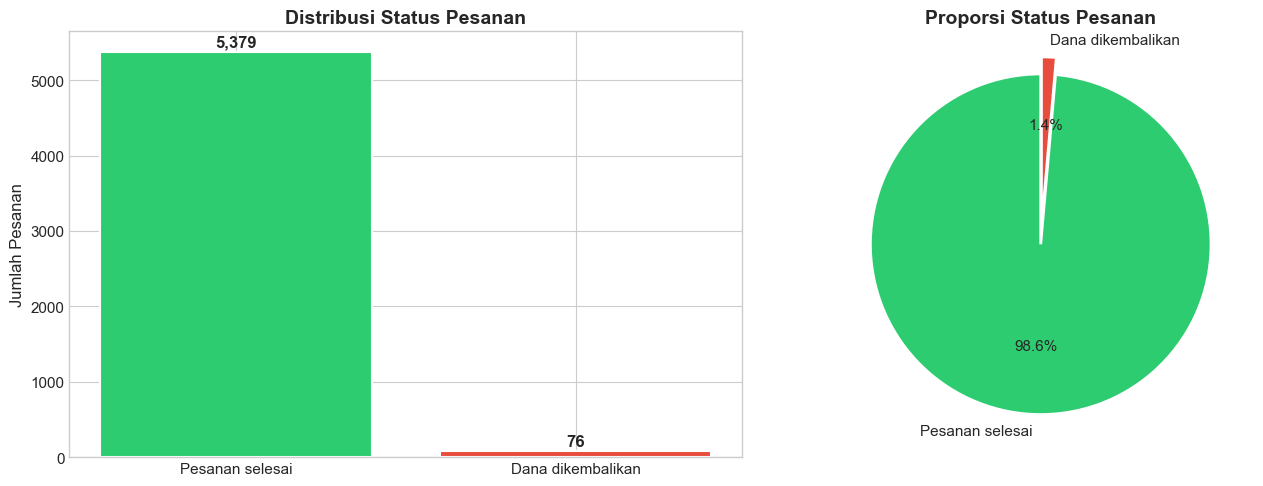


Ringkasan:
  Pesanan selesai: 5,379 (98.6%)
  Dana dikembalikan: 76 (1.4%)


In [10]:
# Distribusi status pesanan
status_counts = df['Status_Pesanan'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Pesanan', fontweight='bold')
axes[0].set_ylabel('Jumlah Pesanan')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0, 0.1],
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Status Pesanan', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nRingkasan:')
for status, count in status_counts.items():
    print(f'  {status}: {count:,} ({count/len(df)*100:.1f}%)')

### 3.6 Distribusi Kategori Produk

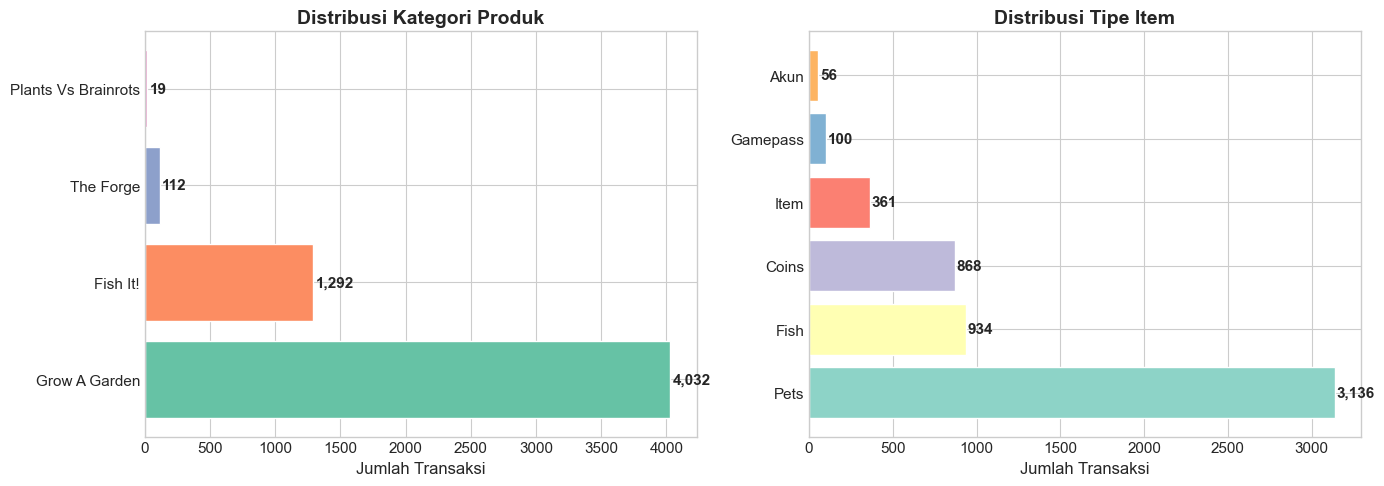

In [11]:
# Distribusi kategori produk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kategori_counts = df['Kategori'].value_counts()
tipe_counts = df['Tipe_Item'].value_counts()

# Kategori
colors_kat = sns.color_palette('Set2', len(kategori_counts))
bars = axes[0].barh(kategori_counts.index, kategori_counts.values, color=colors_kat, edgecolor='white')
axes[0].set_title('Distribusi Kategori Produk', fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')
for bar, val in zip(bars, kategori_counts.values):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', ha='left', va='center', fontweight='bold')

# Tipe Item
colors_tipe = sns.color_palette('Set3', len(tipe_counts))
bars = axes[1].barh(tipe_counts.index, tipe_counts.values, color=colors_tipe, edgecolor='white')
axes[1].set_title('Distribusi Tipe Item', fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi')
for bar, val in zip(bars, tipe_counts.values):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.7 Tren Penjualan Bulanan

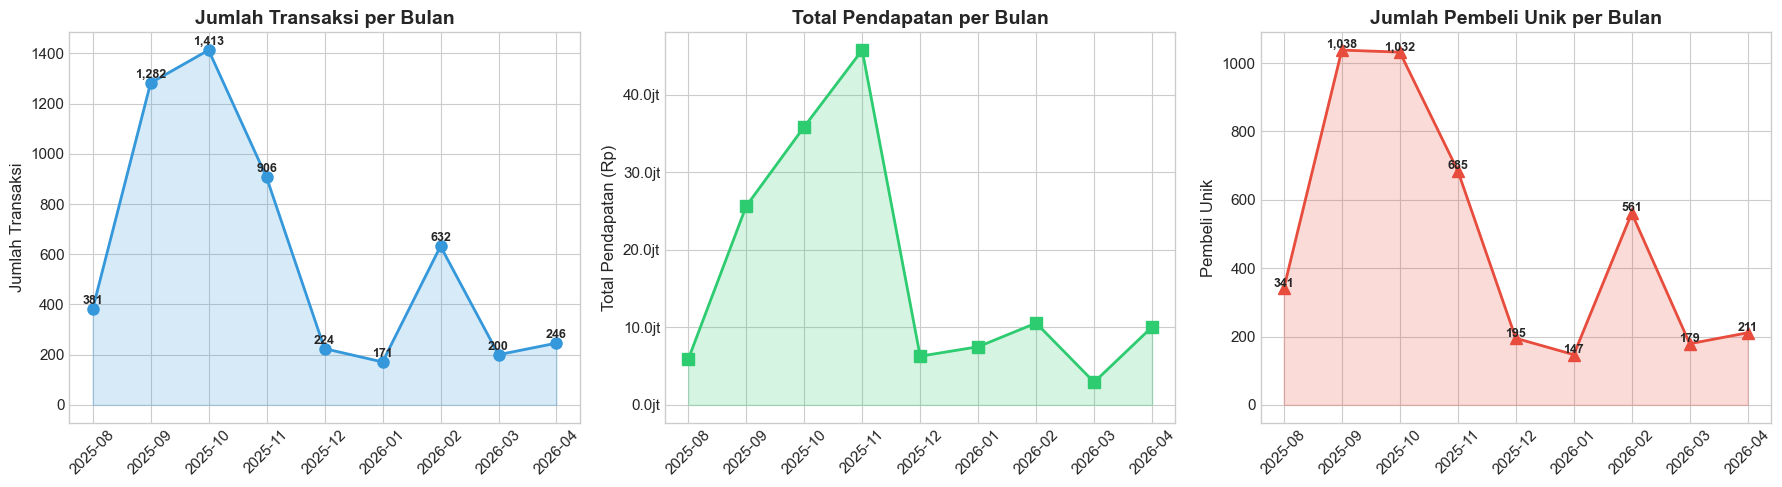


Ringkasan Tren Bulanan:
Bulan_str  Jumlah_Transaksi  Total_Pendapatan  Pembeli_Unik
  2025-08               381           5878148           341
  2025-09              1282          25646677          1038
  2025-10              1413          35891561          1032
  2025-11               906          45783096           685
  2025-12               224           6286596           195
  2026-01               171           7504244           147
  2026-02               632          10561602           561
  2026-03               200           2930488           179
  2026-04               246          10064108           211


In [12]:
# Konversi tanggal untuk analisis tren
df['Tanggal_Dibuat'] = pd.to_datetime(df['Tanggal_Dibuat'])
df['Bulan'] = df['Tanggal_Dibuat'].dt.to_period('M')

# Tren bulanan
tren_bulanan = df.groupby('Bulan').agg(
    Jumlah_Transaksi=('Nomor_Pesanan', 'count'),
    Total_Pendapatan=('Total_Pendapatan', 'sum'),
    Pembeli_Unik=('Nama_Pembeli', 'nunique')
).reset_index()
tren_bulanan['Bulan_str'] = tren_bulanan['Bulan'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Jumlah Transaksi
axes[0].plot(tren_bulanan['Bulan_str'], tren_bulanan['Jumlah_Transaksi'], 
             marker='o', color='#3498db', linewidth=2, markersize=8)
axes[0].fill_between(range(len(tren_bulanan)), tren_bulanan['Jumlah_Transaksi'], alpha=0.2, color='#3498db')
axes[0].set_title('Jumlah Transaksi per Bulan', fontweight='bold')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(tren_bulanan['Jumlah_Transaksi']):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Total Pendapatan
axes[1].plot(tren_bulanan['Bulan_str'], tren_bulanan['Total_Pendapatan'], 
             marker='s', color='#2ecc71', linewidth=2, markersize=8)
axes[1].fill_between(range(len(tren_bulanan)), tren_bulanan['Total_Pendapatan'], alpha=0.2, color='#2ecc71')
axes[1].set_title('Total Pendapatan per Bulan', fontweight='bold')
axes[1].set_ylabel('Total Pendapatan (Rp)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}jt'))

# Pembeli Unik
axes[2].plot(tren_bulanan['Bulan_str'], tren_bulanan['Pembeli_Unik'], 
             marker='^', color='#e74c3c', linewidth=2, markersize=8)
axes[2].fill_between(range(len(tren_bulanan)), tren_bulanan['Pembeli_Unik'], alpha=0.2, color='#e74c3c')
axes[2].set_title('Jumlah Pembeli Unik per Bulan', fontweight='bold')
axes[2].set_ylabel('Pembeli Unik')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(tren_bulanan['Pembeli_Unik']):
    axes[2].text(i, v + 5, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRingkasan Tren Bulanan:')
print(tren_bulanan[['Bulan_str', 'Jumlah_Transaksi', 'Total_Pendapatan', 'Pembeli_Unik']].to_string(index=False))

### 3.8 Top 10 Produk dan Pembeli

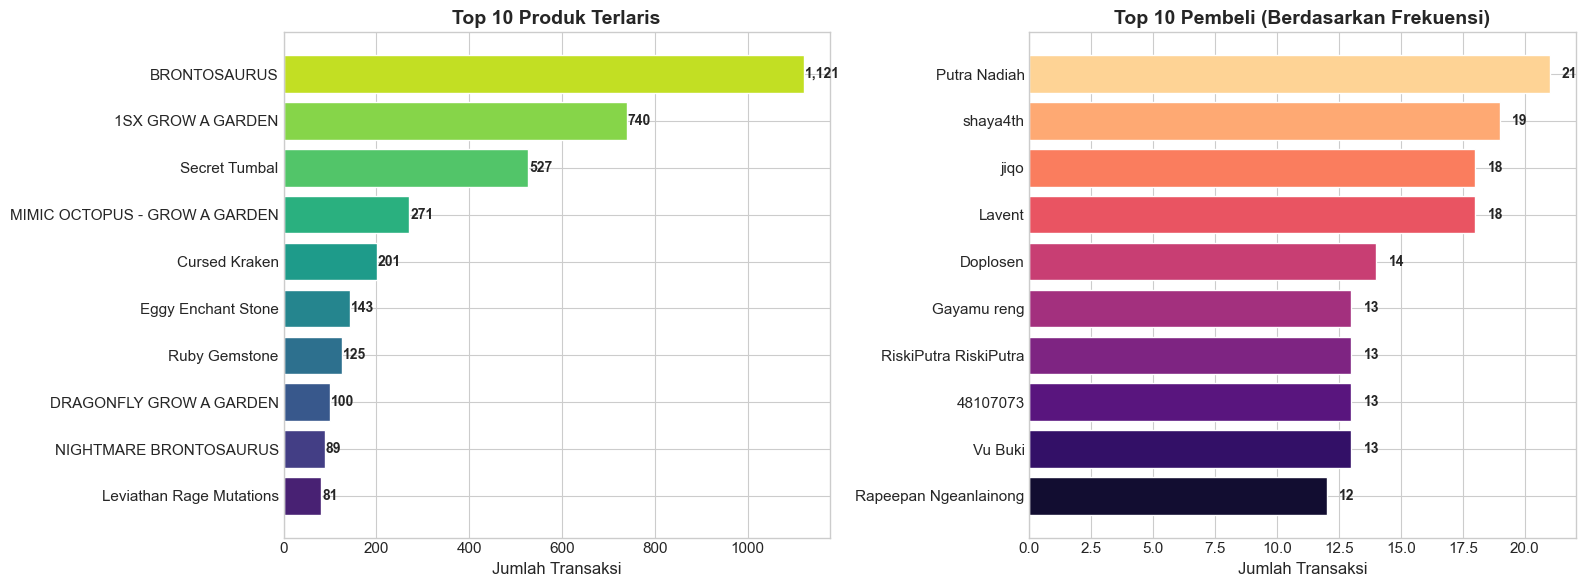

In [13]:
# Top 10 Produk Terlaris
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_produk = df['Nama_Produk'].value_counts().head(10)
colors_produk = sns.color_palette('viridis', 10)
bars = axes[0].barh([str(x) for x in top_produk.index[::-1]], top_produk.values[::-1], color=colors_produk, edgecolor='white')
axes[0].set_title('Top 10 Produk Terlaris', fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')
for bar, val in zip(bars, top_produk.values[::-1]):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', ha='left', va='center', fontweight='bold', fontsize=10)

# Top 10 Pembeli
top_pembeli = df['Nama_Pembeli'].value_counts().head(10)
colors_pembeli = sns.color_palette('magma', 10)
bars = axes[1].barh([str(x) for x in top_pembeli.index[::-1]], top_pembeli.values[::-1], color=colors_pembeli, edgecolor='white')
axes[1].set_title('Top 10 Pembeli (Berdasarkan Frekuensi)', fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi')
for bar, val in zip(bars, top_pembeli.values[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 3.9 Distribusi Harga Jual dan Total Pendapatan

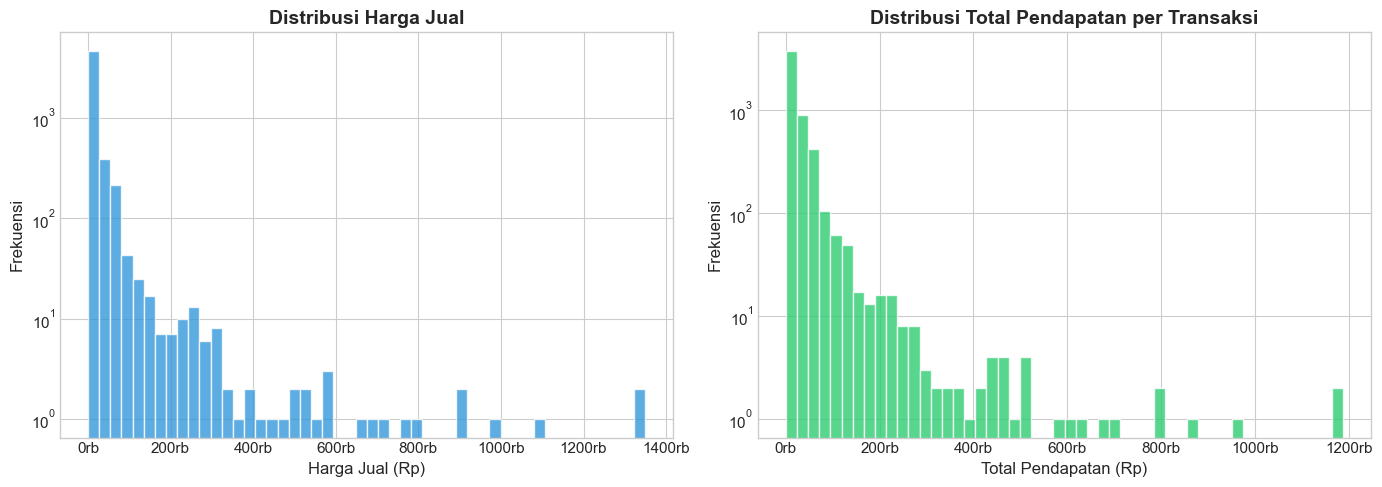

In [14]:
# Distribusi Harga Jual dan Total Pendapatan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Harga Jual (log scale)
axes[0].hist(df['Harga_Jual'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Harga Jual', fontweight='bold')
axes[0].set_xlabel('Harga Jual (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_yscale('log')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}rb'))

# Histogram Total Pendapatan (log scale)
axes[1].hist(df['Total_Pendapatan'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Total Pendapatan per Transaksi', fontweight='bold')
axes[1].set_xlabel('Total Pendapatan (Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_yscale('log')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}rb'))

plt.tight_layout()
plt.show()

---
## 4. Pra-pemrosesan Data (Data Preprocessing)

Pada tahap ini dilakukan pembersihan dan persiapan data sebelum digunakan untuk membangun model RFM. Langkah-langkah yang dilakukan meliputi:
1. Filter transaksi dengan status "Pesanan selesai"
2. Konversi tipe data kolom tanggal
3. Penanganan missing values
4. Seleksi kolom yang relevan untuk analisis RFM

### 4.1 Filter Status Pesanan

In [15]:
# Filter hanya transaksi yang berhasil (Pesanan selesai)
print(f'Jumlah data sebelum filter: {len(df):,}')
print(f'\nDistribusi status pesanan sebelum filter:')
print(df['Status_Pesanan'].value_counts())

# Filter
df_clean = df[df['Status_Pesanan'] == 'Pesanan selesai'].copy()

print(f'\nJumlah data setelah filter: {len(df_clean):,}')
print(f'Data yang dihapus (Dana dikembalikan): {len(df) - len(df_clean):,} baris')
print(f'Jumlah pembeli unik setelah filter: {df_clean["Nama_Pembeli"].nunique():,}')

Jumlah data sebelum filter: 5,455

Distribusi status pesanan sebelum filter:
Status_Pesanan
Pesanan selesai      5379
Dana dikembalikan      76
Name: count, dtype: int64

Jumlah data setelah filter: 5,379
Data yang dihapus (Dana dikembalikan): 76 baris
Jumlah pembeli unik setelah filter: 3,975


### 4.2 Konversi Tipe Data dan Penanganan Missing Values

In [16]:
# Konversi kolom tanggal ke datetime
kolom_tanggal = ['Tanggal_Dibuat', 'Tanggal_Dibayar_Pembeli', 'Tanggal_Dikirim', 'Tanggal_Pesanan_Selesai']

for col in kolom_tanggal:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
    print(f'{col}: {df_clean[col].dtype} — Missing: {df_clean[col].isnull().sum()}')

# Cek missing values setelah konversi
print(f'\nTotal missing values pada data bersih:')
missing_clean = df_clean.isnull().sum()
print(missing_clean[missing_clean > 0])
if missing_clean.sum() == 0:
    print('✅ Tidak ada missing values')

Tanggal_Dibuat: datetime64[ns] — Missing: 0
Tanggal_Dibayar_Pembeli: datetime64[ns] — Missing: 0
Tanggal_Dikirim: datetime64[ns] — Missing: 0
Tanggal_Pesanan_Selesai: datetime64[ns] — Missing: 0

Total missing values pada data bersih:
Series([], dtype: int64)
✅ Tidak ada missing values


### 4.3 Seleksi Kolom untuk Analisis RFM

In [17]:
# Kolom yang dibutuhkan untuk analisis RFM:
# - Nama_Pembeli: identitas pelanggan
# - Tanggal_Dibuat: untuk menghitung Recency
# - Nomor_Pesanan: untuk menghitung Frequency
# - Total_Pendapatan: untuk menghitung Monetary

kolom_rfm = ['Nama_Pembeli', 'Tanggal_Dibuat', 'Nomor_Pesanan', 'Total_Pendapatan']
df_rfm_raw = df_clean[kolom_rfm].copy()

print(f'Dataset untuk analisis RFM:')
print(f'  Jumlah baris: {len(df_rfm_raw):,}')
print(f'  Jumlah kolom: {df_rfm_raw.shape[1]}')
print(f'  Pembeli unik: {df_rfm_raw["Nama_Pembeli"].nunique():,}')
print(f'\nSampel data:')
df_rfm_raw.head(10)

Dataset untuk analisis RFM:
  Jumlah baris: 5,379
  Jumlah kolom: 4
  Pembeli unik: 3,975

Sampel data:


,Nama_Pembeli,Tanggal_Dibuat,Nomor_Pesanan,Total_Pendapatan
0,Naufal Falah,2025-08-30 00:02:29,OD000000144952313,3525
1,Sean,2025-08-29 23:59:16,OD000000144952233,27072
2,Afandi Kurniawan,2025-08-29 23:40:52,OD000000144951849,3525
3,Muhammad Nafif Muazzam,2025-08-29 22:44:25,OD000000144950215,3525
4,Sirius Achtar,2025-08-29 22:36:42,OD000000144949933,3525
5,Christian Jansen,2025-08-29 22:32:41,OD000000144949797,3432
6,Christian Jansen,2025-08-29 22:32:41,OD000000144949796,35250
7,Valen,2025-08-29 22:29:19,OD000000144949657,4371
8,Muhammad Miftachul Rizki,2025-08-29 22:28:06,OD000000144949618,3525
9,Aditya Dwi Putra,2025-08-29 22:27:55,OD000000144949612,8460


---
## 5. Pembentukan Model RFM (RFM Modeling)

Model RFM mengkuantifikasi perilaku pelanggan berdasarkan tiga metrik utama:

| Metrik | Deskripsi | Perhitungan |
|--------|-----------|-------------|
| **Recency (R)** | Seberapa baru transaksi terakhir | Selisih hari antara tanggal referensi dengan tanggal transaksi terakhir |
| **Frequency (F)** | Seberapa sering bertransaksi | Jumlah total transaksi unik per pelanggan |
| **Monetary (M)** | Seberapa besar nilai transaksi | Total pendapatan dari seluruh transaksi per pelanggan |

Semakin **kecil** nilai Recency, semakin **baik** (pelanggan baru saja bertransaksi). Semakin **besar** nilai Frequency dan Monetary, semakin **baik** (pelanggan sering bertransaksi dengan nilai besar).

### 5.1 Menentukan Tanggal Referensi (Snapshot Date)

In [18]:
# Tanggal referensi = tanggal terakhir transaksi + 1 hari
snapshot_date = df_rfm_raw['Tanggal_Dibuat'].max() + pd.Timedelta(days=1)

print(f'Tanggal transaksi pertama : {df_rfm_raw["Tanggal_Dibuat"].min()}')
print(f'Tanggal transaksi terakhir: {df_rfm_raw["Tanggal_Dibuat"].max()}')
print(f'Tanggal referensi         : {snapshot_date}')
print(f'Rentang data              : {(df_rfm_raw["Tanggal_Dibuat"].max() - df_rfm_raw["Tanggal_Dibuat"].min()).days} hari')

Tanggal transaksi pertama : 2025-08-02 07:47:12
Tanggal transaksi terakhir: 2026-04-29 21:39:47
Tanggal referensi         : 2026-04-30 21:39:47
Rentang data              : 270 hari


### 5.2 Perhitungan Nilai RFM

In [19]:
# Menghitung nilai RFM untuk setiap pelanggan
df_rfm = df_rfm_raw.groupby('Nama_Pembeli').agg(
    Recency=('Tanggal_Dibuat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Nomor_Pesanan', 'nunique'),
    Monetary=('Total_Pendapatan', 'sum')
).reset_index()

print(f'Tabel RFM berhasil dibuat!')
print(f'Jumlah pelanggan: {len(df_rfm):,}')
print(f'\n10 Data Pertama Tabel RFM:')
df_rfm.head(10)

Tabel RFM berhasil dibuat!
Jumlah pelanggan: 3,975

10 Data Pertama Tabel RFM:


,Nama_Pembeli,Recency,Frequency,Monetary
0,48107073,182,11,1146200
1,01 A Daffa Al Buchori,80,1,19360
2,012_Ketut Manik Damariyanti,232,1,25344
3,03_Aisy Meiza Prameswari _7C,238,1,4371
4,0472_ I Nyoman Augie Widyadhana,248,1,4400
5,160_Lian Eric Junico,82,1,20020
6,17970026 Stainly Sandalwood Gustamar,252,1,5280
7,19_040_ Ivanddo Yehezkiel Silaban,224,1,44000
8,23-220 Daniel Amadeo Rumahorbo,187,1,19360
9,29 OOI SHENG,158,3,112200


### 5.3 Statistik Deskriptif RFM

In [20]:
# Statistik deskriptif nilai RFM
print('STATISTIK DESKRIPTIF NILAI RFM')
print('='*60)
rfm_stats = df_rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)
print(rfm_stats)
print(f'\nInterpretasi:')
print(f'  • Rata-rata Recency  : {df_rfm["Recency"].mean():.0f} hari (terakhir bertransaksi)')
print(f'  • Rata-rata Frequency: {df_rfm["Frequency"].mean():.2f} transaksi per pelanggan')
print(f'  • Rata-rata Monetary : Rp {df_rfm["Monetary"].mean():,.0f} per pelanggan')
print(f'  • Median Frequency   : {df_rfm["Frequency"].median():.0f} (sebagian besar pelanggan hanya bertransaksi {df_rfm["Frequency"].median():.0f}x)')
print(f'  • Max Monetary       : Rp {df_rfm["Monetary"].max():,.0f} (pelanggan dengan pengeluaran tertinggi)')

STATISTIK DESKRIPTIF NILAI RFM
       Recency  Frequency    Monetary
count  3975.00    3975.00     3975.00
mean    164.10       1.35    37609.54
std      67.78       1.13    89492.92
min       1.00       1.00      166.00
25%     108.00       1.00     6952.00
50%     185.00       1.00    16940.00
75%     217.00       1.00    35200.00
max     271.00      20.00  1519760.00

Interpretasi:
  • Rata-rata Recency  : 164 hari (terakhir bertransaksi)
  • Rata-rata Frequency: 1.35 transaksi per pelanggan
  • Rata-rata Monetary : Rp 37,610 per pelanggan
  • Median Frequency   : 1 (sebagian besar pelanggan hanya bertransaksi 1x)
  • Max Monetary       : Rp 1,519,760 (pelanggan dengan pengeluaran tertinggi)


### 5.4 Visualisasi Distribusi RFM

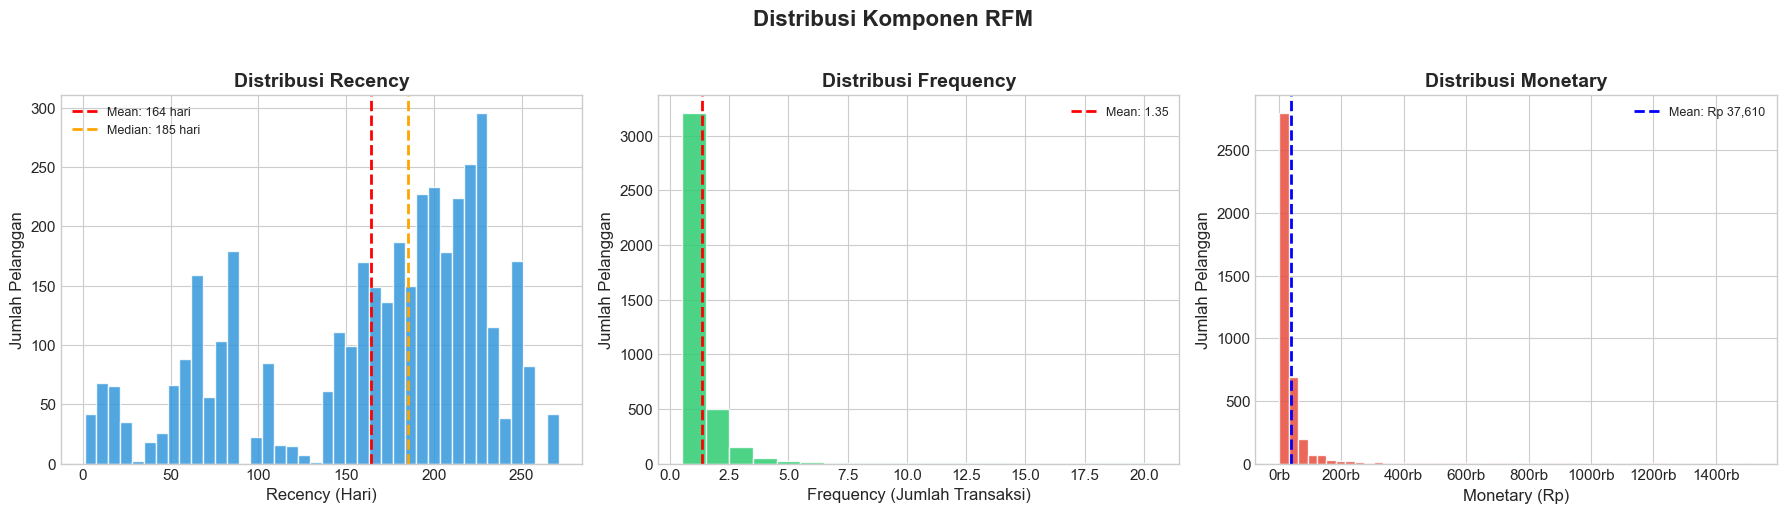

In [21]:
# Visualisasi distribusi setiap komponen RFM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
axes[0].hist(df_rfm['Recency'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df_rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_rfm["Recency"].mean():.0f} hari')
axes[0].axvline(df_rfm['Recency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df_rfm["Recency"].median():.0f} hari')
axes[0].set_title('Distribusi Recency', fontweight='bold')
axes[0].set_xlabel('Recency (Hari)')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].legend(fontsize=9)

# Frequency
axes[1].hist(df_rfm['Frequency'], bins=range(1, df_rfm['Frequency'].max()+2), 
             color='#2ecc71', edgecolor='white', alpha=0.85, align='left')
axes[1].axvline(df_rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_rfm["Frequency"].mean():.2f}')
axes[1].set_title('Distribusi Frequency', fontweight='bold')
axes[1].set_xlabel('Frequency (Jumlah Transaksi)')
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].legend(fontsize=9)

# Monetary
axes[2].hist(df_rfm['Monetary'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[2].axvline(df_rfm['Monetary'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: Rp {df_rfm["Monetary"].mean():,.0f}')
axes[2].set_title('Distribusi Monetary', fontweight='bold')
axes[2].set_xlabel('Monetary (Rp)')
axes[2].set_ylabel('Jumlah Pelanggan')
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}rb'))
axes[2].legend(fontsize=9)

plt.suptitle('Distribusi Komponen RFM', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Korelasi Antar Komponen RFM

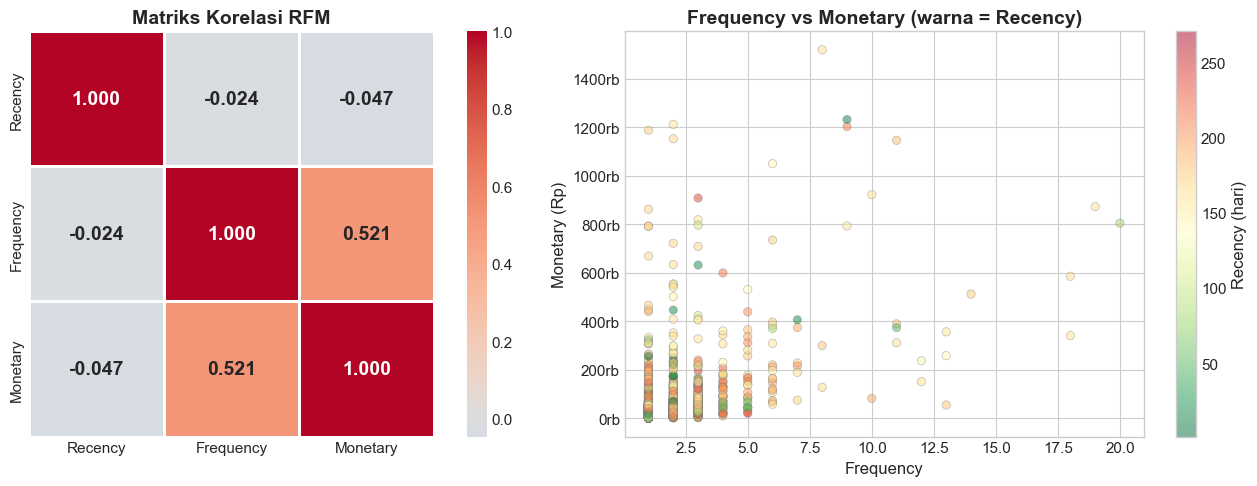

In [22]:
# Korelasi antar komponen RFM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap korelasi
corr_matrix = df_rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=2, ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Matriks Korelasi RFM', fontweight='bold')

# Scatter plot Frequency vs Monetary
axes[1].scatter(df_rfm['Frequency'], df_rfm['Monetary'], alpha=0.5, 
                c=df_rfm['Recency'], cmap='RdYlGn_r', edgecolors='gray', linewidth=0.5)
axes[1].set_title('Frequency vs Monetary (warna = Recency)', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (Rp)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}rb'))
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Recency (hari)')

plt.tight_layout()
plt.show()

---
## 6. Normalisasi Data dan Deteksi Outlier

Sebelum diterapkan algoritma K-Means, data RFM perlu dinormalisasi karena:
1. Skala ketiga variabel RFM berbeda jauh (Recency dalam hari, Frequency dalam jumlah, Monetary dalam rupiah)
2. K-Means menggunakan jarak Euclidean yang sensitif terhadap perbedaan skala
3. Outlier dapat memengaruhi hasil clustering secara signifikan

### 6.1 Deteksi Outlier Menggunakan Box Plot

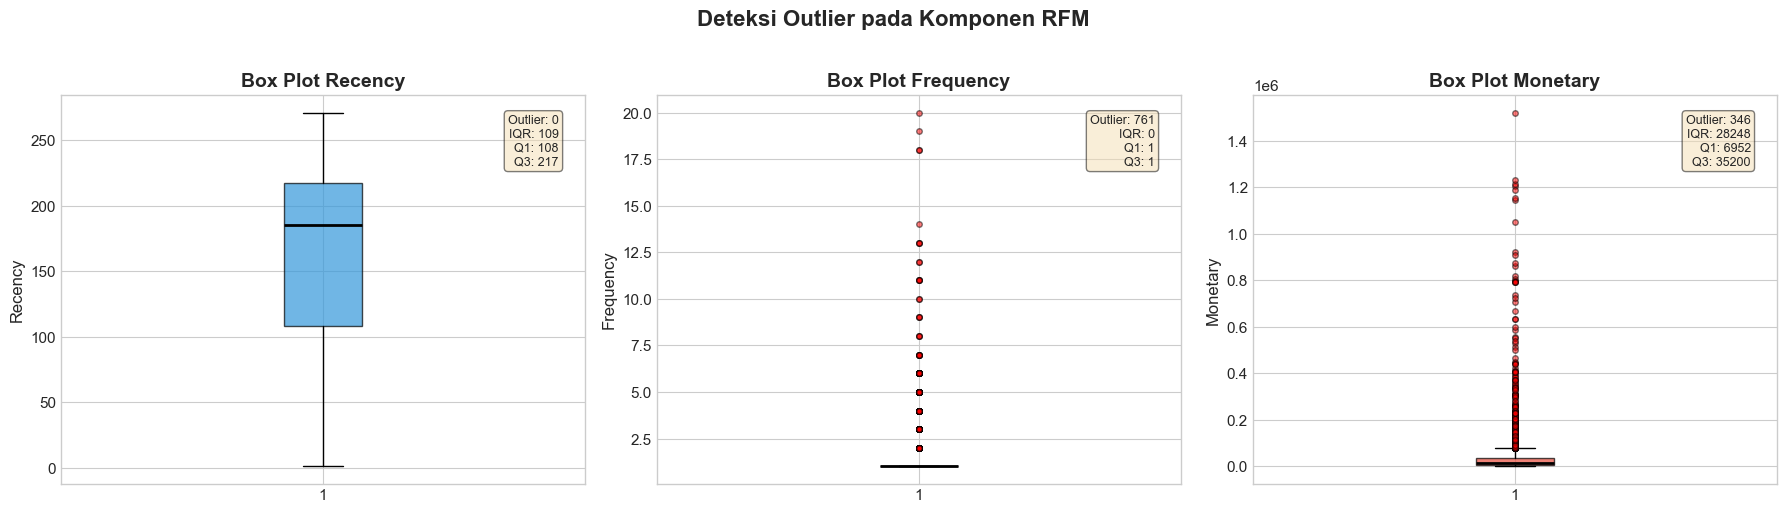

In [23]:
# Box plot untuk deteksi outlier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

komponen = ['Recency', 'Frequency', 'Monetary']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (col, color) in enumerate(zip(komponen, colors)):
    bp = axes[i].boxplot(df_rfm[col], patch_artist=True, 
                         boxprops=dict(facecolor=color, alpha=0.7),
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    axes[i].set_title(f'Box Plot {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    
    # Hitung outlier menggunakan IQR
    Q1 = df_rfm[col].quantile(0.25)
    Q3 = df_rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_rfm[(df_rfm[col] < lower) | (df_rfm[col] > upper)]
    axes[i].text(0.95, 0.95, f'Outlier: {len(outliers)}\nIQR: {IQR:.0f}\nQ1: {Q1:.0f}\nQ3: {Q3:.0f}',
                 transform=axes[i].transAxes, fontsize=9, verticalalignment='top',
                 horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Deteksi Outlier pada Komponen RFM', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Penanganan Outlier dengan Log Transformation

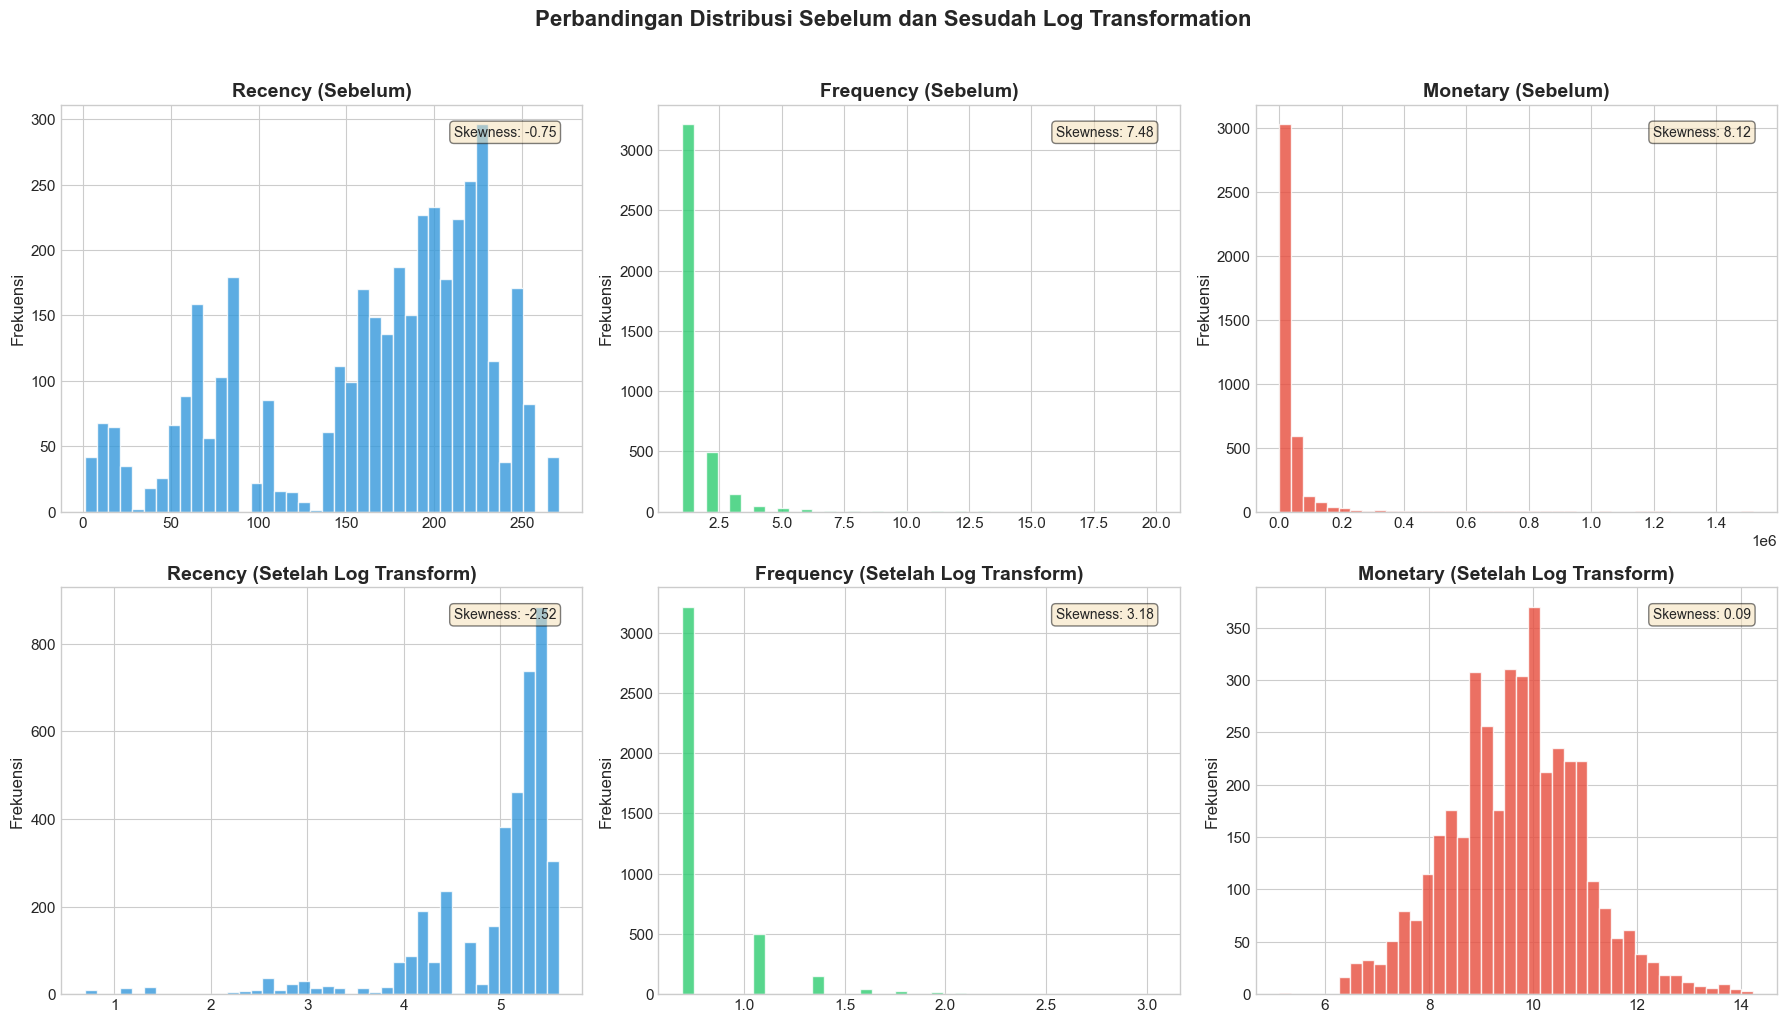

In [24]:
# Log Transformation untuk menangani skewness dan outlier
# Menggunakan log1p (log(1+x)) untuk menghindari log(0)

df_rfm_log = df_rfm.copy()
df_rfm_log['Recency_log'] = np.log1p(df_rfm_log['Recency'])
df_rfm_log['Frequency_log'] = np.log1p(df_rfm_log['Frequency'])
df_rfm_log['Monetary_log'] = np.log1p(df_rfm_log['Monetary'])

# Perbandingan distribusi sebelum dan sesudah log transformation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

komponen_orig = ['Recency', 'Frequency', 'Monetary']
komponen_log = ['Recency_log', 'Frequency_log', 'Monetary_log']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (orig, log_col, color) in enumerate(zip(komponen_orig, komponen_log, colors)):
    # Sebelum
    axes[0][i].hist(df_rfm_log[orig], bins=40, color=color, edgecolor='white', alpha=0.8)
    axes[0][i].set_title(f'{orig} (Sebelum)', fontweight='bold')
    axes[0][i].set_ylabel('Frekuensi')
    skew_before = df_rfm_log[orig].skew()
    axes[0][i].text(0.95, 0.95, f'Skewness: {skew_before:.2f}',
                     transform=axes[0][i].transAxes, fontsize=10, va='top', ha='right',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Sesudah
    axes[1][i].hist(df_rfm_log[log_col], bins=40, color=color, edgecolor='white', alpha=0.8)
    axes[1][i].set_title(f'{orig} (Setelah Log Transform)', fontweight='bold')
    axes[1][i].set_ylabel('Frekuensi')
    skew_after = df_rfm_log[log_col].skew()
    axes[1][i].text(0.95, 0.95, f'Skewness: {skew_after:.2f}',
                     transform=axes[1][i].transAxes, fontsize=10, va='top', ha='right',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Perbandingan Distribusi Sebelum dan Sesudah Log Transformation', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Standarisasi Data dengan StandardScaler

In [25]:
# Standarisasi menggunakan StandardScaler
# StandardScaler mengubah data sehingga memiliki mean=0 dan std=1

scaler = StandardScaler()
rfm_features = df_rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']]
rfm_scaled = scaler.fit_transform(rfm_features)

# Konversi ke DataFrame
df_rfm_scaled = pd.DataFrame(rfm_scaled, 
                              columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

print('Statistik Data Setelah Standarisasi:')
print('='*60)
print(df_rfm_scaled.describe().round(4))
print(f'\n✅ Data berhasil distandarisasi (mean ≈ 0, std ≈ 1)')

Statistik Data Setelah Standarisasi:
       Recency_scaled  Frequency_scaled  Monetary_scaled
count       3975.0000         3975.0000        3975.0000
mean           0.0000            0.0000          -0.0000
std            1.0001            1.0001           1.0001
min           -5.7236           -0.4157          -3.5575
25%           -0.3316           -0.4157          -0.6337
50%            0.3891           -0.4157           0.0645
75%            0.6032           -0.4157           0.6379
max            0.9017            8.3057           3.5902

✅ Data berhasil distandarisasi (mean ≈ 0, std ≈ 1)


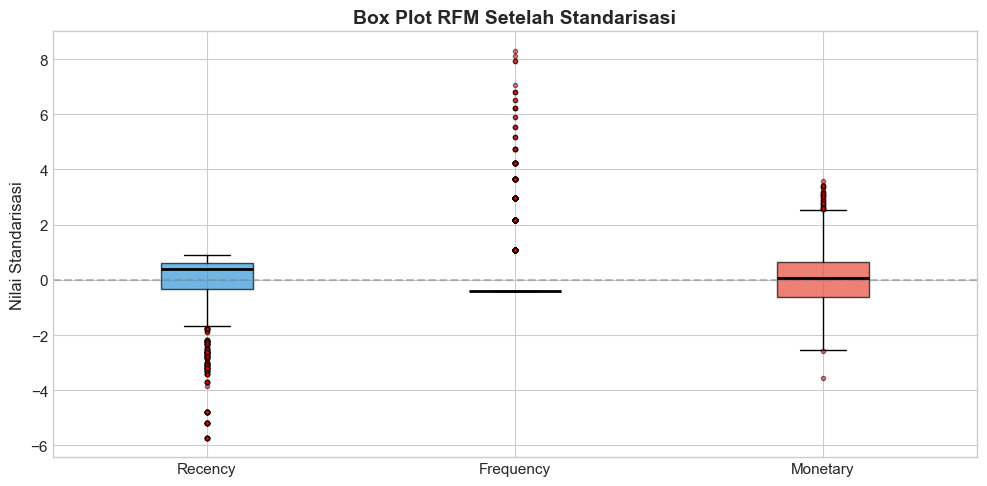

In [26]:
# Box plot setelah standarisasi
fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot([df_rfm_scaled['Recency_scaled'], 
                 df_rfm_scaled['Frequency_scaled'], 
                 df_rfm_scaled['Monetary_scaled']],
                patch_artist=True,
                labels=['Recency', 'Frequency', 'Monetary'],
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Box Plot RFM Setelah Standarisasi', fontweight='bold', fontsize=14)
ax.set_ylabel('Nilai Standarisasi')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 7. Penentuan Jumlah Cluster Optimal

Penentuan jumlah cluster (K) optimal merupakan langkah penting dalam K-Means Clustering. Dalam penelitian ini digunakan **tiga metode** untuk memvalidasi jumlah cluster optimal:

1. **Metode Elbow**: Mengidentifikasi titik "siku" pada grafik inertia (WCSS)
2. **Silhouette Score**: Mengukur seberapa baik objek berada dalam clusternya sendiri dibandingkan cluster lain
3. **Davies-Bouldin Index**: Mengukur rata-rata kemiripan antar cluster (nilai lebih kecil = lebih baik)

### 7.1 Metode Elbow (WCSS / Inertia)

In [27]:
# Metode Elbow
K_range = range(2, 11)
inertias = []
silhouette_scores = []
db_scores = []

print('Menghitung metrik untuk K = 2 sampai K = 10...\n')

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    
    inertia = kmeans.inertia_
    sil_score = silhouette_score(rfm_scaled, labels)
    db_score = davies_bouldin_score(rfm_scaled, labels)
    
    inertias.append(inertia)
    silhouette_scores.append(sil_score)
    db_scores.append(db_score)
    
    print(f'  K={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}')

print('\n✅ Perhitungan selesai!')

Menghitung metrik untuk K = 2 sampai K = 10...



  K=2: Inertia=8330.10, Silhouette=0.4504, Davies-Bouldin=1.0519


  K=3: Inertia=6006.98, Silhouette=0.4126, Davies-Bouldin=1.0006


  K=4: Inertia=4438.11, Silhouette=0.3758, Davies-Bouldin=0.9029


  K=5: Inertia=3615.57, Silhouette=0.3913, Davies-Bouldin=0.8751


  K=6: Inertia=2834.67, Silhouette=0.4313, Davies-Bouldin=0.7952


  K=7: Inertia=2471.19, Silhouette=0.3995, Davies-Bouldin=0.7979


  K=8: Inertia=2199.57, Silhouette=0.4065, Davies-Bouldin=0.7954


  K=9: Inertia=1962.51, Silhouette=0.4172, Davies-Bouldin=0.8517


  K=10: Inertia=1787.35, Silhouette=0.4150, Davies-Bouldin=0.8313

✅ Perhitungan selesai!


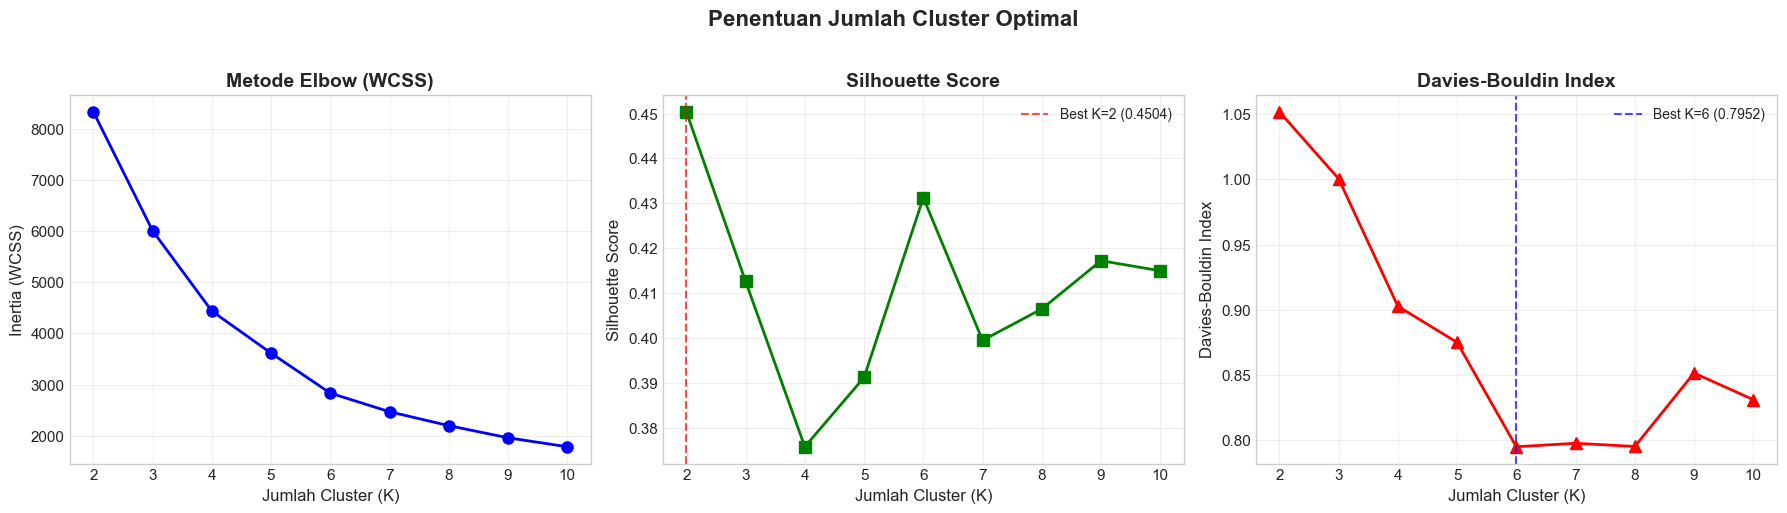


Hasil Evaluasi:
  • Silhouette Score tertinggi pada K = 2
  • Davies-Bouldin Index terendah pada K = 6


In [28]:
# Visualisasi ketiga metode penentuan K optimal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Metode Elbow (WCSS)', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# 2. Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'gs-', linewidth=2, markersize=8)
best_sil_k = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_sil_k, color='red', linestyle='--', alpha=0.7, 
                label=f'Best K={best_sil_k} ({max(silhouette_scores):.4f})')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 3. Davies-Bouldin Index
axes[2].plot(K_range, db_scores, 'r^-', linewidth=2, markersize=8)
best_db_k = list(K_range)[np.argmin(db_scores)]
axes[2].axvline(x=best_db_k, color='blue', linestyle='--', alpha=0.7,
                label=f'Best K={best_db_k} ({min(db_scores):.4f})')
axes[2].set_title('Davies-Bouldin Index', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (K)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_xticks(list(K_range))
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nHasil Evaluasi:')
print(f'  • Silhouette Score tertinggi pada K = {best_sil_k}')
print(f'  • Davies-Bouldin Index terendah pada K = {best_db_k}')

### 7.2 Tabel Ringkasan Metrik Evaluasi

In [29]:
# Tabel ringkasan semua metrik
eval_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia (WCSS)': [f'{x:.2f}' for x in inertias],
    'Silhouette Score': [f'{x:.4f}' for x in silhouette_scores],
    'Davies-Bouldin Index': [f'{x:.4f}' for x in db_scores]
})

print('TABEL RINGKASAN METRIK EVALUASI CLUSTER')
print('='*70)
print(eval_df.to_string(index=False))
print('='*70)

TABEL RINGKASAN METRIK EVALUASI CLUSTER
 K Inertia (WCSS) Silhouette Score Davies-Bouldin Index
 2        8330.10           0.4504               1.0519
 3        6006.98           0.4126               1.0006
 4        4438.11           0.3758               0.9029
 5        3615.57           0.3913               0.8751
 6        2834.67           0.4313               0.7952
 7        2471.19           0.3995               0.7979
 8        2199.57           0.4065               0.7954
 9        1962.51           0.4172               0.8517
10        1787.35           0.4150               0.8313


### 7.3 Silhouette Analysis per Cluster

Jumlah cluster optimal yang dipilih: K = 2
Berdasarkan Silhouette Score tertinggi: 0.4504


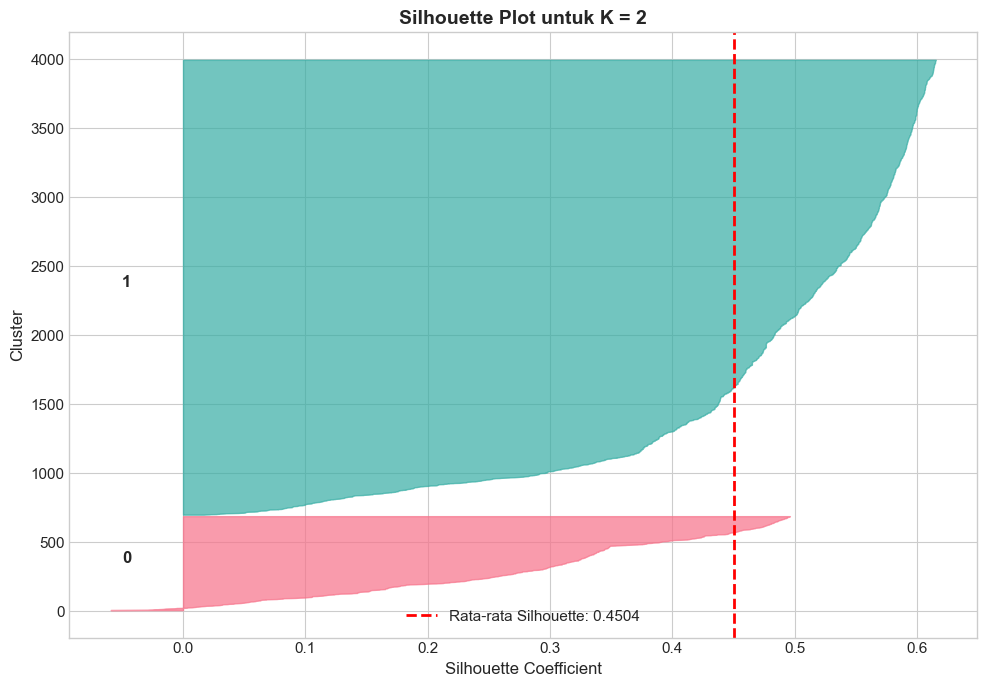

In [30]:
# Silhouette analysis untuk K optimal
# Menggunakan K yang dipilih berdasarkan evaluasi di atas
optimal_k = best_sil_k
print(f'Jumlah cluster optimal yang dipilih: K = {optimal_k}')
print(f'Berdasarkan Silhouette Score tertinggi: {max(silhouette_scores):.4f}')

# Silhouette plot
fig, ax = plt.subplots(figsize=(10, 7))

kmeans_temp = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
cluster_labels = kmeans_temp.fit_predict(rfm_scaled)
silhouette_avg = silhouette_score(rfm_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(rfm_scaled, cluster_labels)

y_lower = 10
colors_sil = sns.color_palette('husl', optimal_k)

for i in range(optimal_k):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=colors_sil[i], edgecolor=colors_sil[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold', fontsize=12)
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=2,
           label=f'Rata-rata Silhouette: {silhouette_avg:.4f}')
ax.set_title(f'Silhouette Plot untuk K = {optimal_k}', fontweight='bold', fontsize=14)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## 8. Implementasi K-Means Clustering

Setelah menentukan jumlah cluster optimal, selanjutnya dilakukan implementasi algoritma **K-Means Clustering** untuk mengelompokkan pelanggan berdasarkan nilai RFM yang telah distandarisasi.

**Algoritma K-Means** bekerja dengan langkah:
1. Inisialisasi K centroid secara acak (menggunakan metode k-means++)
2. Assign setiap data ke centroid terdekat
3. Update posisi centroid berdasarkan rata-rata anggota cluster
4. Ulangi langkah 2-3 hingga konvergen

### 8.1 Training Model K-Means

In [31]:
# Implementasi K-Means Clustering dengan K optimal
kmeans_final = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Fit dan predict
df_rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print('MODEL K-MEANS CLUSTERING')
print('='*60)
print(f'Jumlah cluster (K)     : {optimal_k}')
print(f'Inertia (WCSS)         : {kmeans_final.inertia_:.2f}')
print(f'Jumlah iterasi         : {kmeans_final.n_iter_}')
print(f'Silhouette Score       : {silhouette_score(rfm_scaled, df_rfm["Cluster"]):.4f}')
print(f'Davies-Bouldin Index   : {davies_bouldin_score(rfm_scaled, df_rfm["Cluster"]):.4f}')
print(f'\nDistribusi pelanggan per cluster:')
for cluster in sorted(df_rfm['Cluster'].unique()):
    count = (df_rfm['Cluster'] == cluster).sum()
    pct = count / len(df_rfm) * 100
    print(f'  Cluster {cluster}: {count:,} pelanggan ({pct:.1f}%)')

MODEL K-MEANS CLUSTERING
Jumlah cluster (K)     : 2
Inertia (WCSS)         : 8330.10
Jumlah iterasi         : 26


Silhouette Score       : 0.4504
Davies-Bouldin Index   : 1.0519

Distribusi pelanggan per cluster:
  Cluster 0: 681 pelanggan (17.1%)
  Cluster 1: 3,294 pelanggan (82.9%)


### 8.2 Evaluasi Model Clustering

In [32]:
# Evaluasi detail model clustering
sil_score_final = silhouette_score(rfm_scaled, df_rfm['Cluster'])
db_score_final = davies_bouldin_score(rfm_scaled, df_rfm['Cluster'])

# Menghitung prediksi berbasis centroid (rekonstruksi scaled data)
centroids_final = kmeans_final.cluster_centers_
rfm_scaled_pred = centroids_final[df_rfm['Cluster'].values]

# Metrik Rekonstruksi (MAE, MSE, RMSE, R2 Score)
mae_final = mean_absolute_error(rfm_scaled, rfm_scaled_pred)
mse_final = mean_squared_error(rfm_scaled, rfm_scaled_pred)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(rfm_scaled, rfm_scaled_pred, multioutput='uniform_average')

print('EVALUASI MODEL K-MEANS CLUSTERING')
print('='*60)
print(f'1. Silhouette Score: {sil_score_final:.4f}')
if sil_score_final >= 0.5:
    print('   → Interpretasi: Struktur cluster KUAT (≥ 0.5)')
elif sil_score_final >= 0.25:
    print('   → Interpretasi: Struktur cluster CUKUP BAIK (0.25 - 0.5)')
else:
    print('   → Interpretasi: Struktur cluster LEMAH (< 0.25)')

print(f'\n2. Davies-Bouldin Index: {db_score_final:.4f}')
if db_score_final < 1:
    print('   → Interpretasi: Pemisahan cluster BAIK (< 1.0)')
else:
    print('   → Interpretasi: Pemisahan cluster CUKUP (≥ 1.0)')

print(f'\n3. Inertia (WCSS): {kmeans_final.inertia_:.2f}')
print(f'\n4. Mean Absolute Error (MAE): {mae_final:.4f}')
print(f'5. Mean Squared Error (MSE): {mse_final:.4f}')
print(f'6. Root Mean Squared Error (RMSE): {rmse_final:.4f}')
print(f'7. R2 Score (Variance Explained): {r2_final:.4f}')
print(f'\n8. Jumlah Iterasi Konvergensi: {kmeans_final.n_iter_}')


EVALUASI MODEL K-MEANS CLUSTERING
1. Silhouette Score: 0.4504
   → Interpretasi: Struktur cluster CUKUP BAIK (0.25 - 0.5)

2. Davies-Bouldin Index: 1.0519
   → Interpretasi: Pemisahan cluster CUKUP (≥ 1.0)

3. Inertia (WCSS): 8330.10

4. Mean Absolute Error (MAE): 0.5467
5. Mean Squared Error (MSE): 0.6985
6. Root Mean Squared Error (RMSE): 0.8358
7. R2 Score (Variance Explained): 0.3015

8. Jumlah Iterasi Konvergensi: 26


### 8.3 Visualisasi Cluster dengan PCA 2D

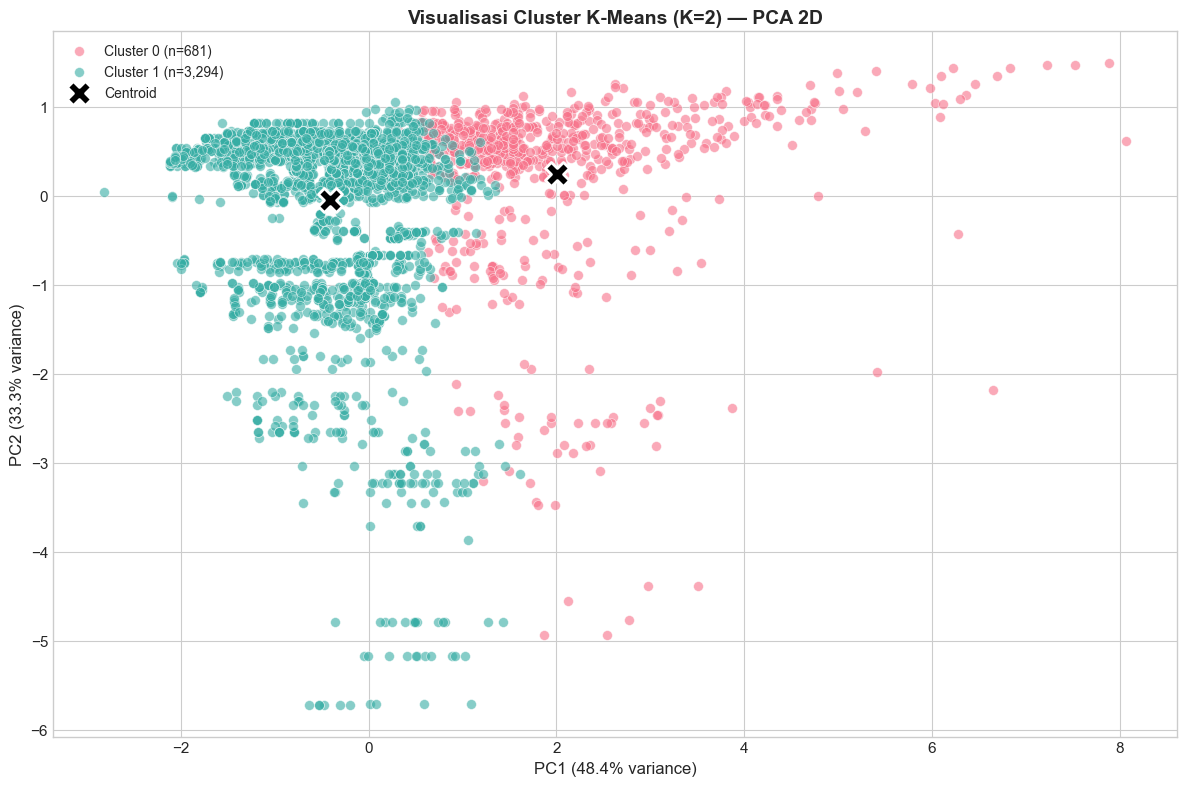

Total variance explained oleh 2 komponen PCA: 81.7%


In [33]:
# Reduksi dimensi menggunakan PCA untuk visualisasi 2D
pca_2d = PCA(n_components=2)
rfm_pca_2d = pca_2d.fit_transform(rfm_scaled)

# Transformasi centroid juga
centroids_pca_2d = pca_2d.transform(kmeans_final.cluster_centers_)

fig, ax = plt.subplots(figsize=(12, 8))

colors_cluster = sns.color_palette('husl', optimal_k)

for i in range(optimal_k):
    mask = df_rfm['Cluster'] == i
    ax.scatter(rfm_pca_2d[mask, 0], rfm_pca_2d[mask, 1], 
               c=[colors_cluster[i]], label=f'Cluster {i} (n={mask.sum():,})',
               alpha=0.6, edgecolors='white', linewidth=0.5, s=50)

# Plot centroids
ax.scatter(centroids_pca_2d[:, 0], centroids_pca_2d[:, 1],
           c='black', marker='X', s=300, edgecolors='white', linewidth=2,
           label='Centroid', zorder=5)

ax.set_title(f'Visualisasi Cluster K-Means (K={optimal_k}) — PCA 2D', fontweight='bold', fontsize=14)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

print(f'Total variance explained oleh 2 komponen PCA: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

### 8.4 Visualisasi Cluster dengan PCA 3D

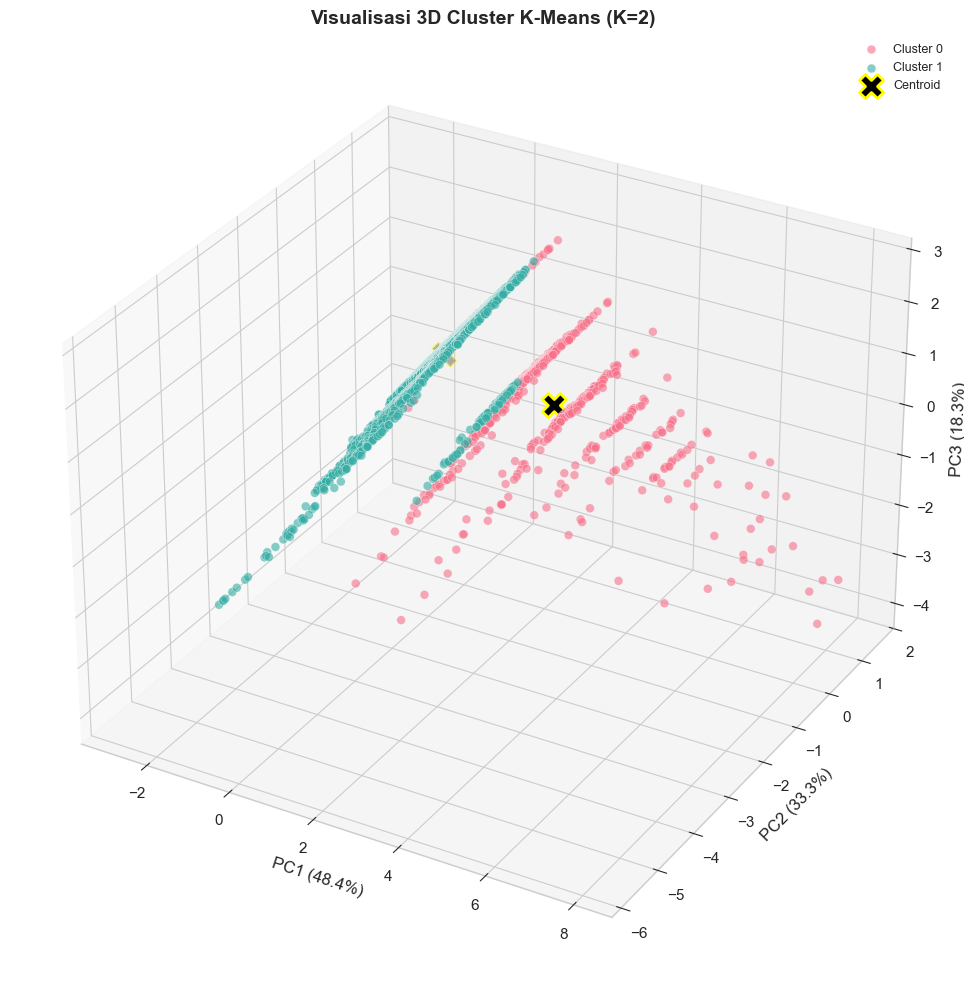

Total variance explained oleh 3 komponen PCA: 100.0%


In [34]:
# Visualisasi 3D menggunakan PCA
pca_3d = PCA(n_components=3)
rfm_pca_3d = pca_3d.fit_transform(rfm_scaled)
centroids_pca_3d = pca_3d.transform(kmeans_final.cluster_centers_)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for i in range(optimal_k):
    mask = df_rfm['Cluster'] == i
    ax.scatter(rfm_pca_3d[mask, 0], rfm_pca_3d[mask, 1], rfm_pca_3d[mask, 2],
               c=[colors_cluster[i]], label=f'Cluster {i}',
               alpha=0.6, edgecolors='white', linewidth=0.3, s=40)

ax.scatter(centroids_pca_3d[:, 0], centroids_pca_3d[:, 1], centroids_pca_3d[:, 2],
           c='black', marker='X', s=300, edgecolors='yellow', linewidth=2,
           label='Centroid', zorder=5)

ax.set_title(f'Visualisasi 3D Cluster K-Means (K={optimal_k})', fontweight='bold', fontsize=14)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Total variance explained oleh 3 komponen PCA: {pca_3d.explained_variance_ratio_.sum()*100:.1f}%')

---
## 9. Analisis dan Interpretasi Segmen Pelanggan

Setelah pelanggan dikelompokkan ke dalam cluster, selanjutnya dilakukan analisis mendalam terhadap karakteristik setiap cluster untuk memberikan **label/nama segmen** yang bermakna secara bisnis.

### 9.1 Statistik RFM per Cluster

In [35]:
# Statistik RFM per cluster
cluster_stats = df_rfm.groupby('Cluster').agg(
    Jumlah_Pelanggan=('Nama_Pembeli', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Recency_Median=('Recency', 'median'),
    Frequency_Mean=('Frequency', 'mean'),
    Frequency_Median=('Frequency', 'median'),
    Monetary_Mean=('Monetary', 'mean'),
    Monetary_Median=('Monetary', 'median'),
    Monetary_Total=('Monetary', 'sum')
).round(2)

print('STATISTIK RFM PER CLUSTER')
print('='*100)
print(cluster_stats.to_string())
print('='*100)

STATISTIK RFM PER CLUSTER
         Jumlah_Pelanggan  Recency_Mean  Recency_Median  Frequency_Mean  Frequency_Median  Monetary_Mean  Monetary_Median  Monetary_Total
Cluster                                                                                                                                  
0                     681        157.92           173.0            2.93               2.0      116481.27          52800.0        79323746
1                    3294        165.37           188.0            1.03               1.0       21303.64          13200.0        70174178


### 9.2 Pemberian Label Segmen Pelanggan

In [36]:
# Analisis karakteristik setiap cluster untuk pemberian label
# Hitung rata-rata global untuk perbandingan
global_r = df_rfm['Recency'].mean()
global_f = df_rfm['Frequency'].mean()
global_m = df_rfm['Monetary'].mean()

print('Perbandingan Rata-rata Cluster vs Rata-rata Global')
print('='*80)
print(f'Rata-rata Global: Recency={global_r:.1f}, Frequency={global_f:.2f}, Monetary=Rp{global_m:,.0f}')
print('-'*80)

segment_labels = {}

for cluster in sorted(df_rfm['Cluster'].unique()):
    subset = df_rfm[df_rfm['Cluster'] == cluster]
    r_mean = subset['Recency'].mean()
    f_mean = subset['Frequency'].mean()
    m_mean = subset['Monetary'].mean()
    
    # Logika pelabelan berdasarkan perbandingan dengan rata-rata
    r_status = '↓ Rendah (Baik)' if r_mean < global_r else '↑ Tinggi (Buruk)'
    f_status = '↑ Tinggi (Baik)' if f_mean > global_f else '↓ Rendah (Buruk)'
    m_status = '↑ Tinggi (Baik)' if m_mean > global_m else '↓ Rendah (Buruk)'
    
    # Tentukan label segmen
    if r_mean < global_r and f_mean > global_f and m_mean > global_m:
        label = 'Champions'
    elif r_mean < global_r and f_mean > global_f:
        label = 'Loyal Customers'
    elif r_mean < global_r and m_mean > global_m:
        label = 'Big Spenders'
    elif r_mean < global_r:
        label = 'New/Recent Customers'
    elif f_mean > global_f and m_mean > global_m:
        label = 'At Risk (Valuable)'
    elif f_mean > global_f:
        label = 'At Risk'
    elif m_mean > global_m:
        label = 'Need Attention'
    else:
        label = 'Hibernating'
    
    segment_labels[cluster] = label
    
    print(f'\nCluster {cluster} — "{label}" ({len(subset):,} pelanggan)')
    print(f'  Recency  : {r_mean:.1f} hari {r_status}')
    print(f'  Frequency: {f_mean:.2f} kali {f_status}')
    print(f'  Monetary : Rp {m_mean:,.0f} {m_status}')

# Assign label ke DataFrame
df_rfm['Segmen'] = df_rfm['Cluster'].map(segment_labels)

print('\n' + '='*80)
print('\nMapping Cluster ke Segmen:')
for k, v in segment_labels.items():
    print(f'  Cluster {k} → {v}')

Perbandingan Rata-rata Cluster vs Rata-rata Global
Rata-rata Global: Recency=164.1, Frequency=1.35, Monetary=Rp37,610
--------------------------------------------------------------------------------

Cluster 0 — "Champions" (681 pelanggan)
  Recency  : 157.9 hari ↓ Rendah (Baik)
  Frequency: 2.93 kali ↑ Tinggi (Baik)
  Monetary : Rp 116,481 ↑ Tinggi (Baik)

Cluster 1 — "Hibernating" (3,294 pelanggan)
  Recency  : 165.4 hari ↑ Tinggi (Buruk)
  Frequency: 1.03 kali ↓ Rendah (Buruk)
  Monetary : Rp 21,304 ↓ Rendah (Buruk)


Mapping Cluster ke Segmen:
  Cluster 0 → Champions
  Cluster 1 → Hibernating


### 9.3 Visualisasi Komposisi Segmen Pelanggan

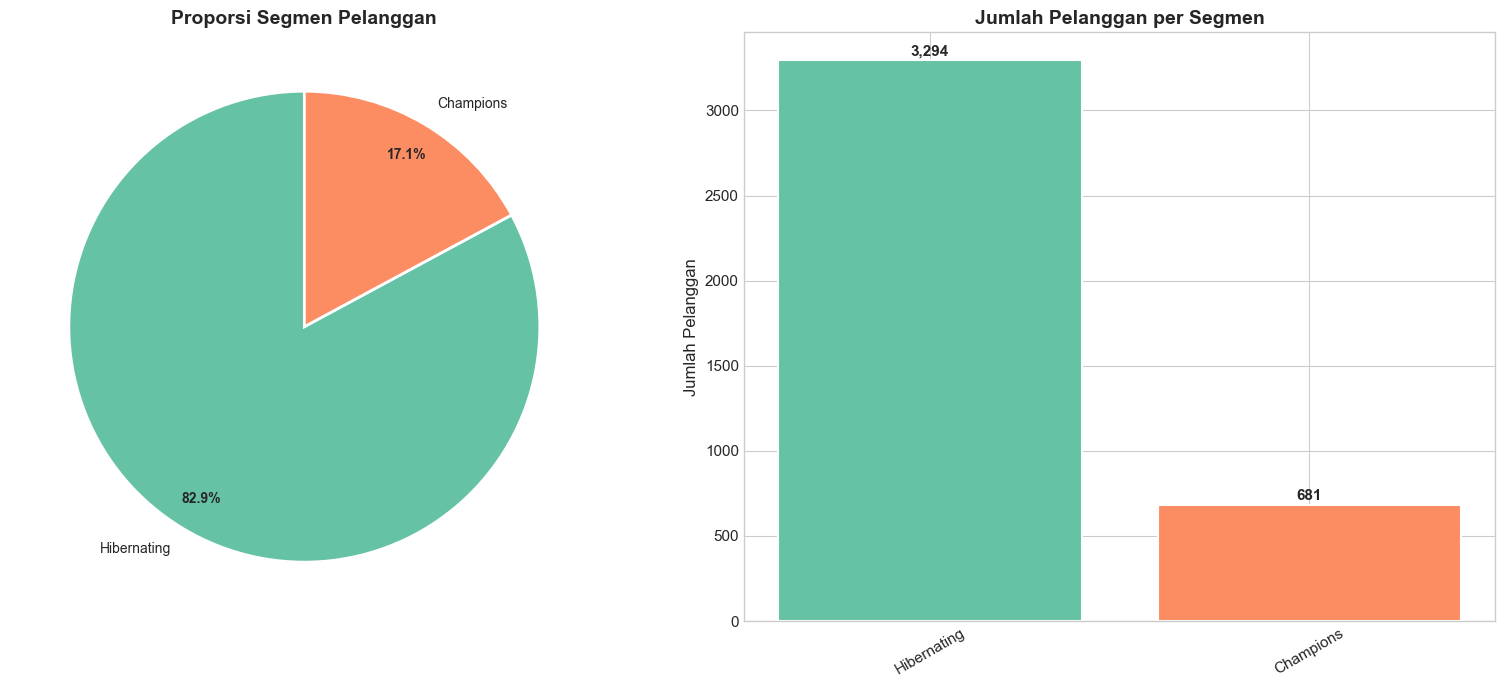

In [37]:
# Pie chart dan bar chart komposisi segmen
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

segmen_counts = df_rfm['Segmen'].value_counts()
colors_segmen = sns.color_palette('Set2', len(segmen_counts))

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    segmen_counts.values, 
    labels=segmen_counts.index,
    autopct='%1.1f%%',
    colors=colors_segmen,
    startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.85
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[0].set_title('Proporsi Segmen Pelanggan', fontweight='bold', fontsize=14)

# Bar chart
bars = axes[1].bar(segmen_counts.index, segmen_counts.values, color=colors_segmen, edgecolor='white', linewidth=1.5)
axes[1].set_title('Jumlah Pelanggan per Segmen', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, segmen_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### 9.4 Heatmap Rata-rata RFM per Cluster

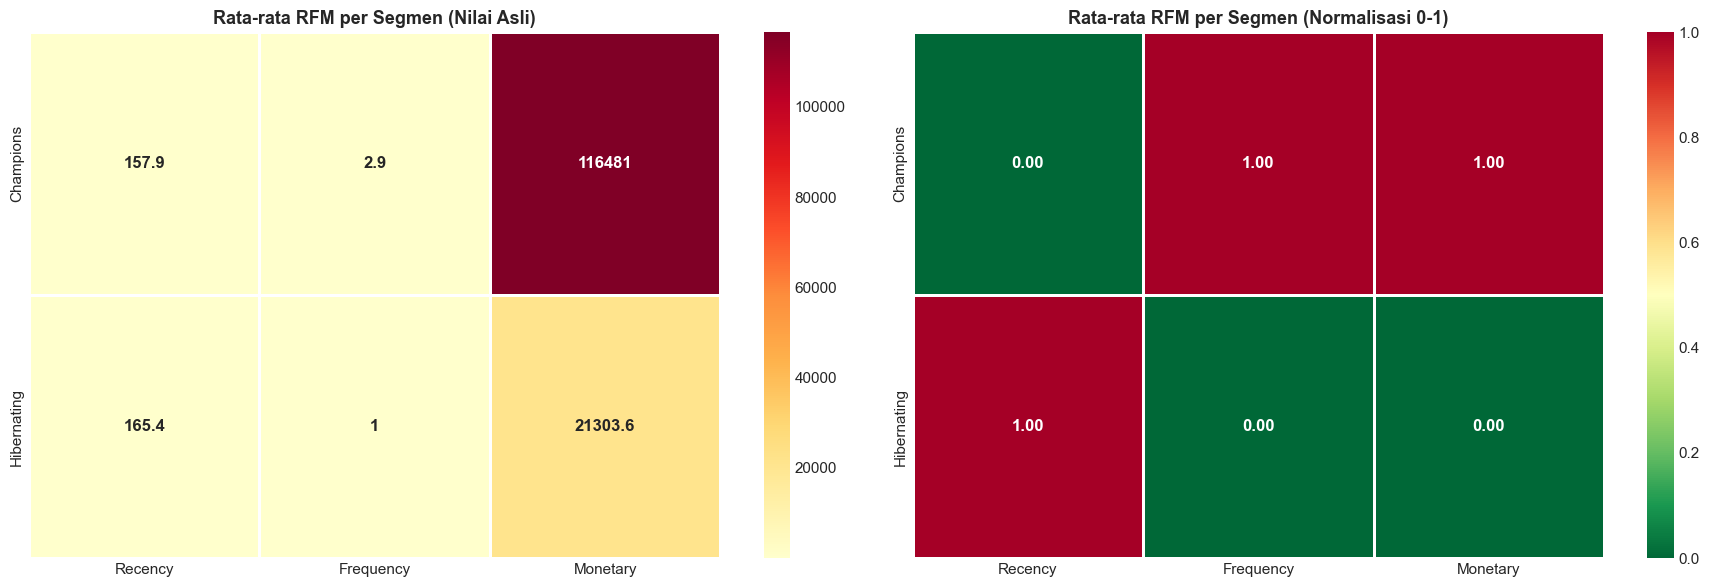

In [38]:
# Heatmap rata-rata RFM per cluster
cluster_means = df_rfm.groupby('Segmen')[['Recency', 'Frequency', 'Monetary']].mean()

# Normalisasi untuk heatmap (min-max per kolom)
cluster_means_norm = cluster_means.copy()
for col in cluster_means_norm.columns:
    min_val = cluster_means_norm[col].min()
    max_val = cluster_means_norm[col].max()
    if max_val > min_val:
        cluster_means_norm[col] = (cluster_means_norm[col] - min_val) / (max_val - min_val)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap nilai asli
sns.heatmap(cluster_means.round(1), annot=True, cmap='YlOrRd', fmt='g',
            linewidths=2, ax=axes[0], annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('Rata-rata RFM per Segmen (Nilai Asli)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('')

# Heatmap normalisasi
sns.heatmap(cluster_means_norm.round(2), annot=True, cmap='RdYlGn_r', fmt='.2f',
            linewidths=2, ax=axes[1], annot_kws={'size': 12, 'weight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_title('Rata-rata RFM per Segmen (Normalisasi 0-1)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 9.5 Radar/Spider Chart per Segmen

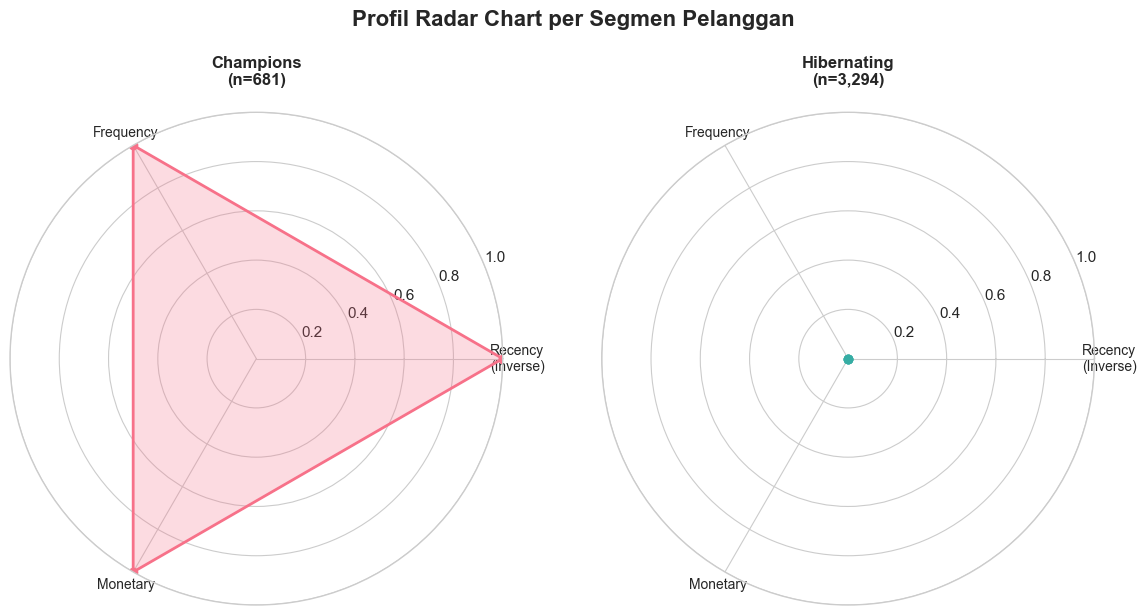

In [39]:
# Radar/Spider Chart untuk setiap segmen
from math import pi

# Normalisasi data untuk radar chart
categories = ['Recency\n(Inverse)', 'Frequency', 'Monetary']
N = len(categories)

# Untuk radar chart, Recency perlu diinversikan (semakin kecil = semakin baik)
radar_data = df_rfm.groupby('Segmen')[['Recency', 'Frequency', 'Monetary']].mean()
radar_data['Recency'] = radar_data['Recency'].max() - radar_data['Recency']  # Inverse

# Min-Max normalisasi
for col in radar_data.columns:
    min_val = radar_data[col].min()
    max_val = radar_data[col].max()
    if max_val > min_val:
        radar_data[col] = (radar_data[col] - min_val) / (max_val - min_val)
    else:
        radar_data[col] = 0.5

# Plot
n_segments = len(radar_data)
cols = min(3, n_segments)
rows = (n_segments + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows), subplot_kw=dict(polar=True))
if n_segments == 1:
    axes = np.array([axes])
axes = axes.flatten()

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

colors_radar = sns.color_palette('husl', n_segments)

for idx, (segmen, row) in enumerate(radar_data.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    
    ax = axes[idx]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.25, color=colors_radar[idx])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    
    count = (df_rfm['Segmen'] == segmen).sum()
    ax.set_title(f'{segmen}\n(n={count:,})', fontweight='bold', fontsize=12, pad=20)

# Sembunyikan axes yang tidak digunakan
for idx in range(n_segments, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Profil Radar Chart per Segmen Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.6 Perbandingan Antar Segmen

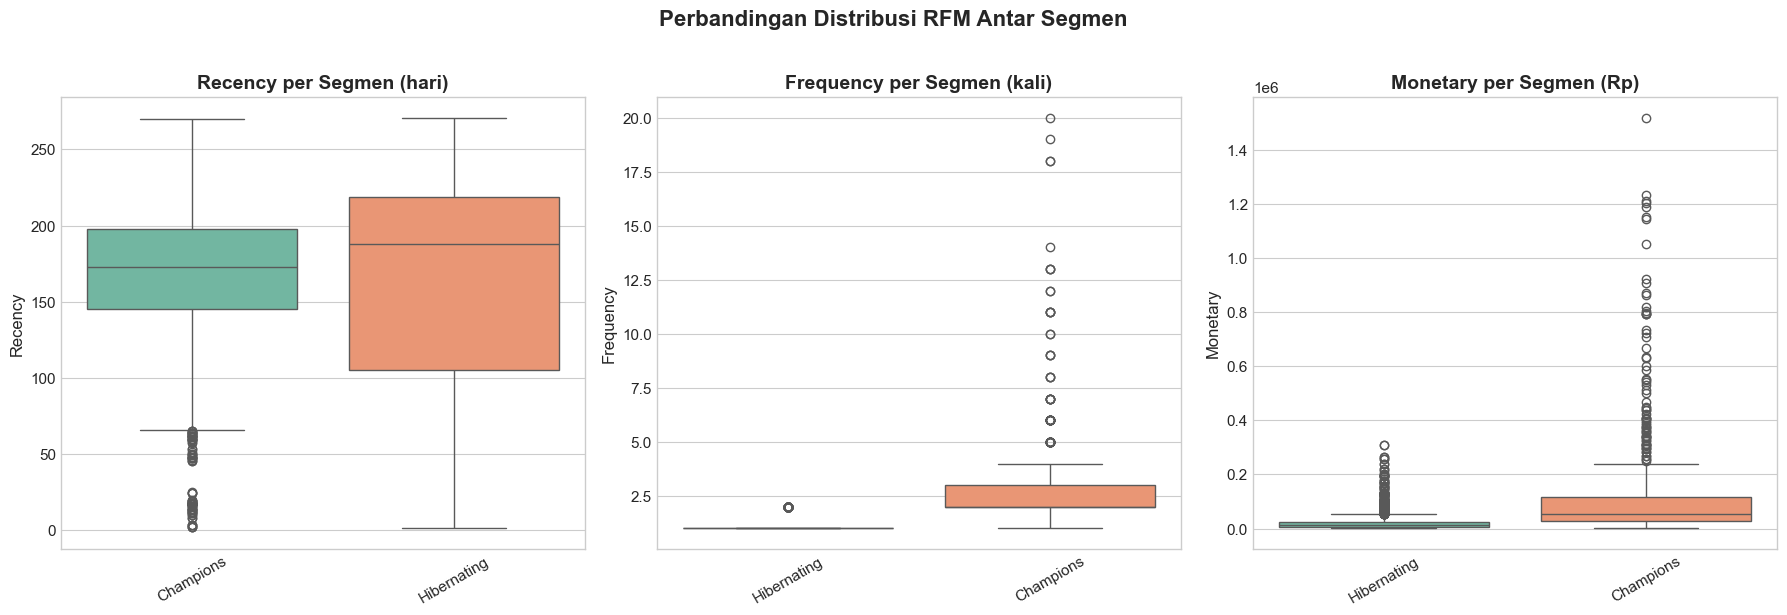

In [40]:
# Perbandingan box plot RFM per segmen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

komponen = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency per Segmen (hari)', 'Frequency per Segmen (kali)', 'Monetary per Segmen (Rp)']

for i, (col, title) in enumerate(zip(komponen, titles)):
    order = df_rfm.groupby('Segmen')[col].mean().sort_values(ascending=True).index
    sns.boxplot(data=df_rfm, x='Segmen', y=col, ax=axes[i], 
                palette='Set2', order=order)
    axes[i].set_title(title, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

plt.suptitle('Perbandingan Distribusi RFM Antar Segmen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.7 Kontribusi Pendapatan per Segmen

KONTRIBUSI PENDAPATAN PER SEGMEN
             Jumlah  Total_Monetary  Rata_Monetary  Pct_Pelanggan  Pct_Revenue
Segmen                                                                        
Champions       681        79323746  116481.271659           17.1         53.1
Hibernating    3294        70174178   21303.636308           82.9         46.9


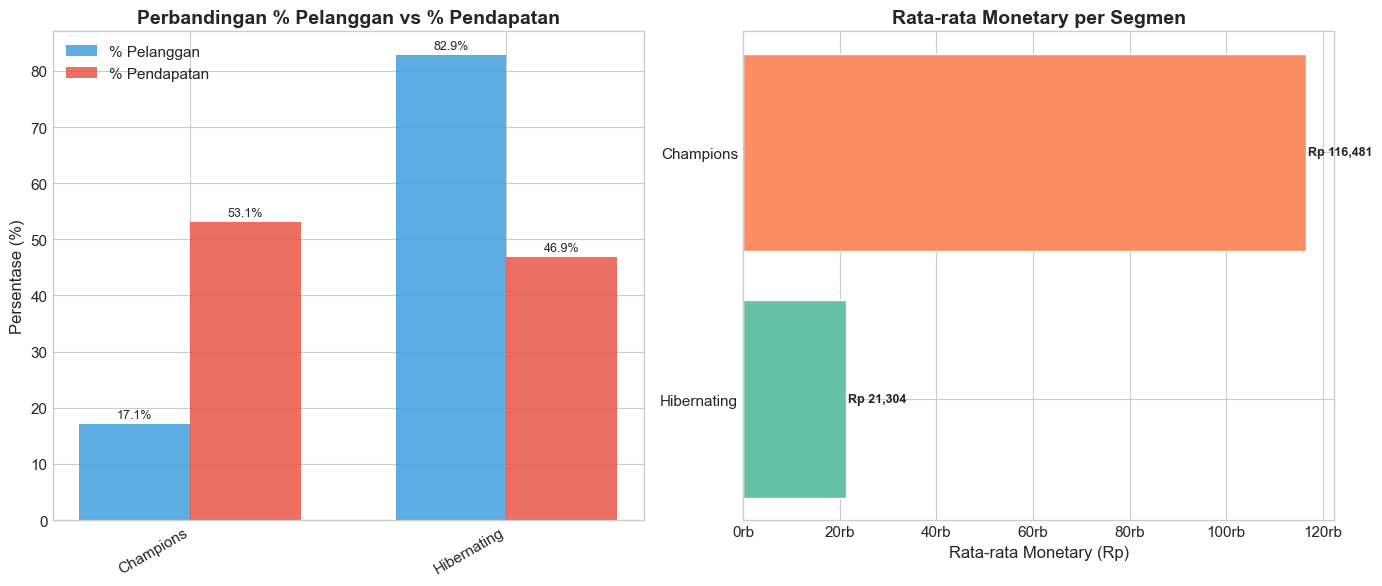

In [41]:
# Kontribusi pendapatan per segmen
segmen_revenue = df_rfm.groupby('Segmen').agg(
    Jumlah=('Nama_Pembeli', 'count'),
    Total_Monetary=('Monetary', 'sum'),
    Rata_Monetary=('Monetary', 'mean')
).sort_values('Total_Monetary', ascending=False)

segmen_revenue['Pct_Pelanggan'] = (segmen_revenue['Jumlah'] / segmen_revenue['Jumlah'].sum() * 100).round(1)
segmen_revenue['Pct_Revenue'] = (segmen_revenue['Total_Monetary'] / segmen_revenue['Total_Monetary'].sum() * 100).round(1)

print('KONTRIBUSI PENDAPATAN PER SEGMEN')
print('='*90)
print(segmen_revenue.to_string())
print('='*90)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Perbandingan % Pelanggan vs % Revenue
x = np.arange(len(segmen_revenue))
width = 0.35

bars1 = axes[0].bar(x - width/2, segmen_revenue['Pct_Pelanggan'], width, 
                     label='% Pelanggan', color='#3498db', alpha=0.8)
bars2 = axes[0].bar(x + width/2, segmen_revenue['Pct_Revenue'], width, 
                     label='% Pendapatan', color='#e74c3c', alpha=0.8)
axes[0].set_title('Perbandingan % Pelanggan vs % Pendapatan', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(segmen_revenue.index, rotation=30, ha='right')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# Rata-rata Monetary per segmen
bars = axes[1].barh(segmen_revenue.index[::-1], segmen_revenue['Rata_Monetary'].values[::-1], 
                     color=sns.color_palette('Set2', len(segmen_revenue)), edgecolor='white')
axes[1].set_title('Rata-rata Monetary per Segmen', fontweight='bold')
axes[1].set_xlabel('Rata-rata Monetary (Rp)')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}rb'))
for bar, val in zip(bars, segmen_revenue['Rata_Monetary'].values[::-1]):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'Rp {val:,.0f}', ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### 9.8 Tabel Ringkasan Segmen Pelanggan

In [42]:
# Tabel ringkasan lengkap segmen pelanggan
ringkasan = df_rfm.groupby('Segmen').agg(
    Jumlah_Pelanggan=('Nama_Pembeli', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2)

ringkasan['Pct_Pelanggan'] = (ringkasan['Jumlah_Pelanggan'] / ringkasan['Jumlah_Pelanggan'].sum() * 100).round(1)
ringkasan['Pct_Revenue'] = (ringkasan['Total_Revenue'] / ringkasan['Total_Revenue'].sum() * 100).round(1)

# Format monetary
ringkasan['Avg_Monetary'] = ringkasan['Avg_Monetary'].apply(lambda x: f'Rp {x:,.0f}')
ringkasan['Total_Revenue'] = ringkasan['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')
ringkasan['Avg_Recency'] = ringkasan['Avg_Recency'].apply(lambda x: f'{x:.0f} hari')
ringkasan['Avg_Frequency'] = ringkasan['Avg_Frequency'].apply(lambda x: f'{x:.2f} kali')

print('='*110)
print('TABEL RINGKASAN SEGMEN PELANGGAN TOKO HATTA - MARKETPLACE ITEMKU')
print('='*110)
print(ringkasan.to_string())
print('='*110)

TABEL RINGKASAN SEGMEN PELANGGAN TOKO HATTA - MARKETPLACE ITEMKU
             Jumlah_Pelanggan Avg_Recency Avg_Frequency Avg_Monetary  Total_Revenue  Pct_Pelanggan  Pct_Revenue
Segmen                                                                                                         
Champions                 681    158 hari     2.93 kali   Rp 116,481  Rp 79,323,746           17.1         53.1
Hibernating              3294    165 hari     1.03 kali    Rp 21,304  Rp 70,174,178           82.9         46.9


---
## 10. Rekomendasi Strategi Penjualan dan Kesimpulan

Berdasarkan hasil segmentasi pelanggan menggunakan model RFM dan algoritma K-Means Clustering, berikut adalah rekomendasi strategi penjualan yang dapat diterapkan oleh Toko Hatta untuk setiap segmen pelanggan.

### 10.1 Rekomendasi Strategi per Segmen

In [43]:
# Rekomendasi strategi per segmen
strategi = {
    'Champions': {
        'deskripsi': 'Pelanggan terbaik dengan transaksi terbaru, frekuensi tinggi, dan nilai besar',
        'strategi': [
            'Berikan reward/loyalty program eksklusif',
            'Tawarkan early access untuk item baru atau langka',
            'Buat program referral dengan bonus untuk setiap pelanggan baru yang direferensikan',
            'Berikan diskon khusus untuk pembelian bundle/paket',
            'Prioritaskan layanan pelanggan (fast response, prioritas pengiriman)'
        ]
    },
    'Loyal Customers': {
        'deskripsi': 'Pelanggan setia yang sering bertransaksi meskipun nilai transaksi tidak terlalu besar',
        'strategi': [
            'Tawarkan upselling item premium dengan diskon khusus',
            'Buat program poin loyalitas yang bisa ditukar dengan item gratis',
            'Kirim notifikasi personal saat ada item baru sesuai preferensi mereka',
            'Berikan free item/bonus kecil sebagai apresiasi',
            'Ajak bergabung ke grup/komunitas pelanggan VIP'
        ]
    },
    'Big Spenders': {
        'deskripsi': 'Pelanggan dengan pengeluaran besar namun frekuensi belum optimal',
        'strategi': [
            'Tawarkan paket bundle/combo dengan harga spesial',
            'Kirim katalog item langka/premium secara berkala',
            'Buat program cashback untuk pembelian berulang',
            'Berikan free delivery/pengiriman instan gratis',
            'Personalisasi rekomendasi produk berdasarkan riwayat pembelian'
        ]
    },
    'New/Recent Customers': {
        'deskripsi': 'Pelanggan baru atau yang baru saja bertransaksi, perlu dipertahankan',
        'strategi': [
            'Kirim pesan welcome dan panduan toko',
            'Tawarkan diskon untuk pembelian kedua (second purchase incentive)',
            'Berikan bonus item gratis untuk pembelian pertama/kedua',
            'Follow up dengan rekomendasi item berdasarkan pembelian pertama',
            'Buat program "New Customer Special" dengan harga khusus'
        ]
    },
    'At Risk (Valuable)': {
        'deskripsi': 'Pelanggan bernilai tinggi yang sudah lama tidak bertransaksi, risiko churn tinggi',
        'strategi': [
            'Kirim pesan win-back dengan penawaran spesial "We Miss You"',
            'Berikan diskon besar atau item gratis untuk kembali bertransaksi',
            'Informasikan item baru yang relevan dengan riwayat pembelian',
            'Tawarkan harga khusus time-limited untuk menciptakan urgency',
            'Hubungi secara personal untuk memahami alasan tidak bertransaksi'
        ]
    },
    'At Risk': {
        'deskripsi': 'Pelanggan yang dulu cukup aktif namun sudah lama tidak bertransaksi',
        'strategi': [
            'Kirim notifikasi re-engagement dengan promo menarik',
            'Tawarkan voucher diskon dengan batas waktu',
            'Informasikan update toko dan item-item baru',
            'Buat flash sale khusus untuk menarik kembali',
            'Pertimbangkan bundle paket dengan harga sangat kompetitif'
        ]
    },
    'Need Attention': {
        'deskripsi': 'Pelanggan dengan potensi yang perlu dikembangkan',
        'strategi': [
            'Kirim rekomendasi produk yang personalized',
            'Tawarkan diskon untuk kategori yang belum pernah dibeli',
            'Buat program cross-selling antar kategori',
            'Berikan informasi tentang promo dan event toko',
            'Tingkatkan engagement melalui konten informatif tentang game'
        ]
    },
    'Hibernating': {
        'deskripsi': 'Pelanggan tidak aktif dengan frekuensi dan nilai transaksi rendah',
        'strategi': [
            'Kirim email/pesan reaktivasi dengan penawaran menarik',
            'Tawarkan diskon besar untuk kembali bertransaksi',
            'Evaluasi apakah segmen ini layak dipertahankan dari segi biaya marketing',
            'Fokuskan sumber daya pada segmen yang lebih potensial',
            'Pertimbangkan campaign massal dengan biaya rendah'
        ]
    }
}

print('REKOMENDASI STRATEGI PENJUALAN PER SEGMEN')
print('='*80)

for segmen in df_rfm['Segmen'].unique():
    if segmen in strategi:
        info = strategi[segmen]
        count = (df_rfm['Segmen'] == segmen).sum()
        pct = count / len(df_rfm) * 100
        print(f'\n📌 Segmen: {segmen} ({count:,} pelanggan | {pct:.1f}%)')
        print(f'   Deskripsi: {info["deskripsi"]}')
        print(f'   Strategi yang Direkomendasikan:')
        for j, s in enumerate(info['strategi'], 1):
            print(f'     {j}. {s}')
    else:
        count = (df_rfm['Segmen'] == segmen).sum()
        print(f'\n📌 Segmen: {segmen} ({count:,} pelanggan)')
        print(f'   (Strategi perlu disesuaikan berdasarkan analisis lebih lanjut)')

print('\n' + '='*80)

REKOMENDASI STRATEGI PENJUALAN PER SEGMEN

📌 Segmen: Champions (681 pelanggan | 17.1%)
   Deskripsi: Pelanggan terbaik dengan transaksi terbaru, frekuensi tinggi, dan nilai besar
   Strategi yang Direkomendasikan:
     1. Berikan reward/loyalty program eksklusif
     2. Tawarkan early access untuk item baru atau langka
     3. Buat program referral dengan bonus untuk setiap pelanggan baru yang direferensikan
     4. Berikan diskon khusus untuk pembelian bundle/paket
     5. Prioritaskan layanan pelanggan (fast response, prioritas pengiriman)

📌 Segmen: Hibernating (3,294 pelanggan | 82.9%)
   Deskripsi: Pelanggan tidak aktif dengan frekuensi dan nilai transaksi rendah
   Strategi yang Direkomendasikan:
     1. Kirim email/pesan reaktivasi dengan penawaran menarik
     2. Tawarkan diskon besar untuk kembali bertransaksi
     3. Evaluasi apakah segmen ini layak dipertahankan dari segi biaya marketing
     4. Fokuskan sumber daya pada segmen yang lebih potensial
     5. Pertimbangkan camp

### 10.2 Ringkasan Visual Strategi per Segmen

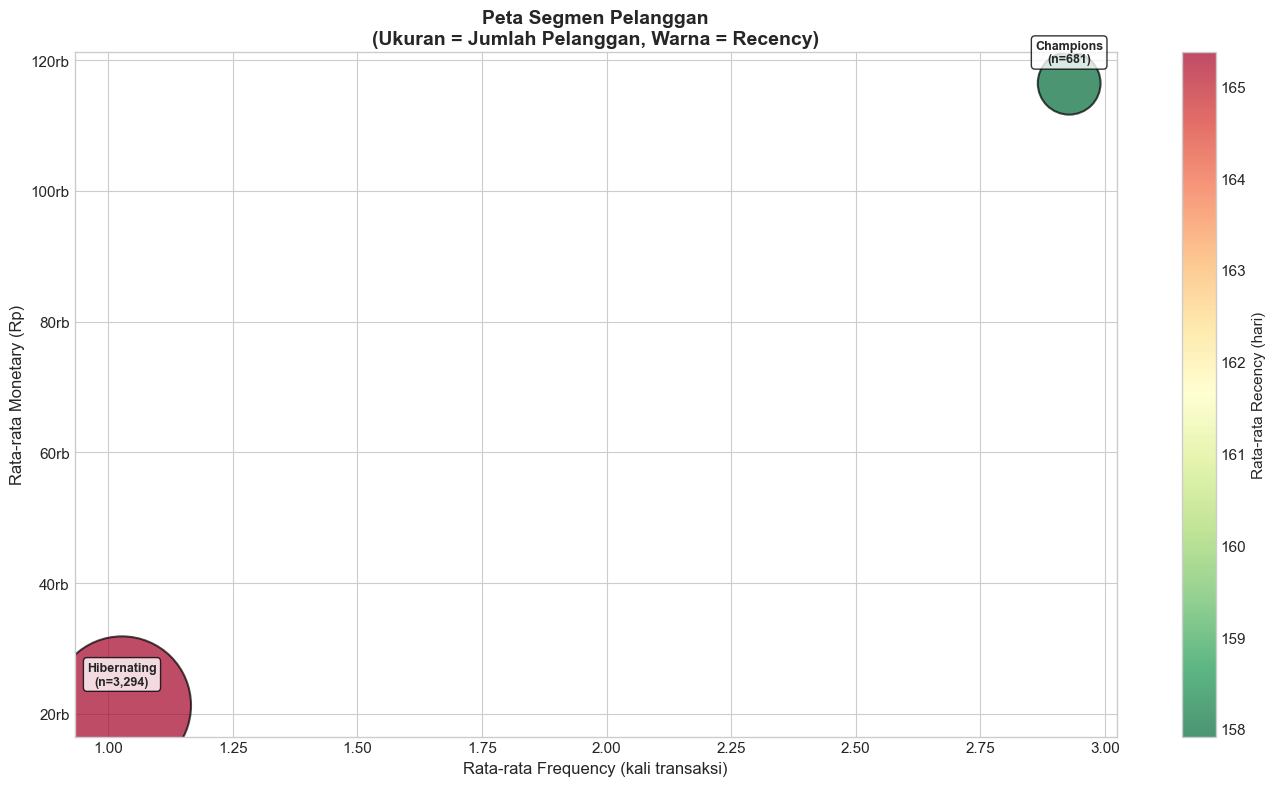

In [44]:
# Visualisasi ringkasan - prioritas aksi per segmen
fig, ax = plt.subplots(figsize=(14, 8))

# Bubble chart: Frequency vs Monetary, size = jumlah pelanggan, color = Recency
segmen_summary = df_rfm.groupby('Segmen').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('Nama_Pembeli', 'count')
)

scatter = ax.scatter(
    segmen_summary['Avg_Frequency'],
    segmen_summary['Avg_Monetary'],
    s=segmen_summary['Count'] * 3,
    c=segmen_summary['Avg_Recency'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)

# Label setiap bubble
for segmen, row in segmen_summary.iterrows():
    ax.annotate(f'{segmen}\n(n={row["Count"]:,.0f})',
                (row['Avg_Frequency'], row['Avg_Monetary']),
                textcoords='offset points', xytext=(0, 15),
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rata-rata Recency (hari)', fontsize=11)

ax.set_title('Peta Segmen Pelanggan\n(Ukuran = Jumlah Pelanggan, Warna = Recency)', 
             fontweight='bold', fontsize=14)
ax.set_xlabel('Rata-rata Frequency (kali transaksi)', fontsize=12)
ax.set_ylabel('Rata-rata Monetary (Rp)', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}rb'))

plt.tight_layout()
plt.show()

### 10.3 Kesimpulan

In [45]:
# Kesimpulan
total_pelanggan = len(df_rfm)
total_transaksi = len(df_clean)

print('='*80)
print('KESIMPULAN PENELITIAN')
print('='*80)
print(f'''
Berdasarkan analisis segmentasi pelanggan menggunakan Model RFM dan Algoritma 
K-Means Clustering pada data transaksi Toko Hatta di Marketplace Itemku, 
dapat disimpulkan sebagai berikut:

1. DATASET
   • Total transaksi yang dianalisis: {total_transaksi:,} transaksi
   • Total pelanggan unik: {total_pelanggan:,} pelanggan
   • Periode data: Agustus 2025 - April 2026 (9 bulan)

2. MODEL RFM
   • Recency rata-rata: {df_rfm["Recency"].mean():.0f} hari
   • Frequency rata-rata: {df_rfm["Frequency"].mean():.2f} kali
   • Monetary rata-rata: Rp {df_rfm["Monetary"].mean():,.0f}

3. CLUSTERING
   • Jumlah cluster optimal: K = {optimal_k}
   • Silhouette Score: {silhouette_score(rfm_scaled, df_rfm["Cluster"]):.4f}
   • Davies-Bouldin Index: {davies_bouldin_score(rfm_scaled, df_rfm["Cluster"]):.4f}

4. SEGMEN PELANGGAN
''')

for segmen in df_rfm['Segmen'].value_counts().index:
    count = (df_rfm['Segmen'] == segmen).sum()
    pct = count / total_pelanggan * 100
    revenue = df_rfm[df_rfm['Segmen'] == segmen]['Monetary'].sum()
    rev_pct = revenue / df_rfm['Monetary'].sum() * 100
    print(f'   • {segmen}: {count:,} pelanggan ({pct:.1f}%) — Kontribusi revenue: {rev_pct:.1f}%')

print(f'''
5. REKOMENDASI
   • Fokus utama pada segmen Champions dan Loyal Customers untuk mempertahankan 
     pendapatan yang sudah ada
   • Implementasi program win-back untuk segmen At Risk agar tidak kehilangan 
     pelanggan bernilai tinggi  
   • Kembangkan strategi onboarding yang baik untuk New/Recent Customers 
     agar menjadi pelanggan loyal
   • Evaluasi biaya marketing untuk segmen Hibernating agar efisien

{'='*80}
''')

KESIMPULAN PENELITIAN



Berdasarkan analisis segmentasi pelanggan menggunakan Model RFM dan Algoritma 
K-Means Clustering pada data transaksi Toko Hatta di Marketplace Itemku, 
dapat disimpulkan sebagai berikut:

1. DATASET
   • Total transaksi yang dianalisis: 5,379 transaksi
   • Total pelanggan unik: 3,975 pelanggan
   • Periode data: Agustus 2025 - April 2026 (9 bulan)

2. MODEL RFM
   • Recency rata-rata: 164 hari
   • Frequency rata-rata: 1.35 kali
   • Monetary rata-rata: Rp 37,610

3. CLUSTERING
   • Jumlah cluster optimal: K = 2
   • Silhouette Score: 0.4504
   • Davies-Bouldin Index: 1.0519

4. SEGMEN PELANGGAN

   • Hibernating: 3,294 pelanggan (82.9%) — Kontribusi revenue: 46.9%
   • Champions: 681 pelanggan (17.1%) — Kontribusi revenue: 53.1%

5. REKOMENDASI
   • Fokus utama pada segmen Champions dan Loyal Customers untuk mempertahankan 
     pendapatan yang sudah ada
   • Implementasi program win-back untuk segmen At Risk agar tidak kehilangan 
     pelanggan bernilai tinggi  
   • Kembangkan s

### 10.4 Ekspor Hasil Segmentasi

In [46]:
# Ekspor hasil segmentasi ke file CSV
output_file = 'Hasil_Segmentasi_Pelanggan_RFM_KMeans.csv'
df_rfm.to_csv(output_file, index=False)
print(f'✅ Hasil segmentasi berhasil diekspor ke: {output_file}')
print(f'   Jumlah baris: {len(df_rfm):,}')
print(f'   Kolom: {df_rfm.columns.tolist()}')
print(f'\nPreview data yang diekspor:')
display(df_rfm.head(10))

# Download file CSV ke komputer lokal jika dijalankan di Google Colab
if is_colab:
    print('\n📥 Mengunduh file CSV...')
    files.download(output_file)
else:
    print('\nℹ️ Dijalankan secara lokal, file CSV disimpan di direktori aktif.')


✅ Hasil segmentasi berhasil diekspor ke: Hasil_Segmentasi_Pelanggan_RFM_KMeans.csv
   Jumlah baris: 3,975
   Kolom: ['Nama_Pembeli', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segmen']

Preview data yang diekspor:


,Nama_Pembeli,Recency,Frequency,Monetary,Cluster,Segmen
0,48107073,182,11,1146200,0,Champions
1,01 A Daffa Al Buchori,80,1,19360,1,Hibernating
2,012_Ketut Manik Damariyanti,232,1,25344,1,Hibernating
3,03_Aisy Meiza Prameswari _7C,238,1,4371,1,Hibernating
4,0472_ I Nyoman Augie Widyadhana,248,1,4400,1,Hibernating
5,160_Lian Eric Junico,82,1,20020,1,Hibernating
6,17970026 Stainly Sandalwood Gustamar,252,1,5280,1,Hibernating
7,19_040_ Ivanddo Yehezkiel Silaban,224,1,44000,1,Hibernating
8,23-220 Daniel Amadeo Rumahorbo,187,1,19360,1,Hibernating
9,29 OOI SHENG,158,3,112200,0,Champions



ℹ️ Dijalankan secara lokal, file CSV disimpan di direktori aktif.


---
## Referensi

1. Hughes, A. M. (1994). *Strategic Database Marketing*. Probus Publishing.
2. MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the fifth Berkeley symposium on mathematical statistics and probability*, 1(14), 281-297.
3. Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.
4. Davies, D. L., & Bouldin, D. W. (1979). A Cluster Separation Measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 1(2), 224-227.
5. Scikit-learn Documentation. https://scikit-learn.org/stable/

---
*Notebook ini dibuat untuk mendukung penelitian segmentasi pelanggan pada Toko Hatta di Marketplace Itemku.*